In [10]:
!pip install scikit-learn --quiet

✅ SparkSession khởi tạo thành công!
   Spark version: 4.0.2

📂 Đọc 9 file CSV từ dataset Olist...
✅ Đọc dữ liệu thành công!

📊 PHẦN 2: EXPLORATORY DATA ANALYSIS (EDA)

📋 Tổng quan các bảng dữ liệu:
Bảng                         Số dòng   Số cột
---------------------------------------------
orders                        99,441        8
items                        112,650        7
customers                     99,441        5
products                      32,951        9
reviews                      104,162        7
sellers                        3,095        4
payments                     103,886        5
geolocation                1,000,163        5
category_translation              71        2

📐 Schema bảng orders:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_d

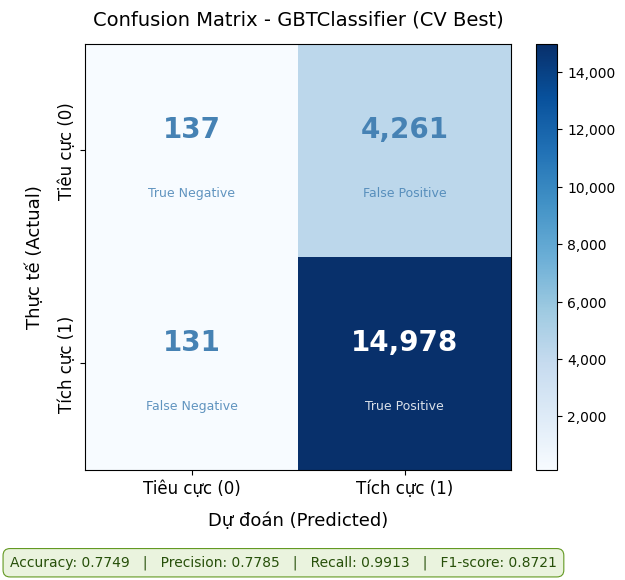

✅ Đã lưu: confusion_matrix_gbt_cv.png

📊 Metrics (tính từ confusion matrix thực tế):
   Accuracy  : 0.7749
   Precision : 0.7785
   Recall    : 0.9913
   F1-score  : 0.8721

📈 PHẦN 9: REGRESSION - 3 MÔ HÌNH

📈 PHẦN 9: REGRESSION - 3 MÔ HÌNH (Pipeline End-to-End)
✅ Target   : payment_value
✅ cat_cols : ['product_category_name_english', 'payment_type', 'customer_state', 'seller_state', 'purchase_month']
✅ num_cols : ['item_count', 'payment_installments', 'product_weight_g', 'product_photos_qty', 'purchase_year', 'purchase_dow', 'product_name_lenght', 'product_description_lenght', 'delivery_days']

📊 Phân bố payment_value (label):
+------+------+----+--------+------+
|  mean|   std| min|     max|median|
+------+------+----+--------+------+
|160.61|220.48|9.59|13664.08|105.29|
+------+------+----+--------+------+

✅ Reg train: 79,158 | test: 19,507

--- 9.1 Linear Regression Pipeline ---

📊 Linear Regression:
   RMSE : 175.0504
   MAE  : 84.3968
   R²   : 0.3481
   Intercept: -18266.9285



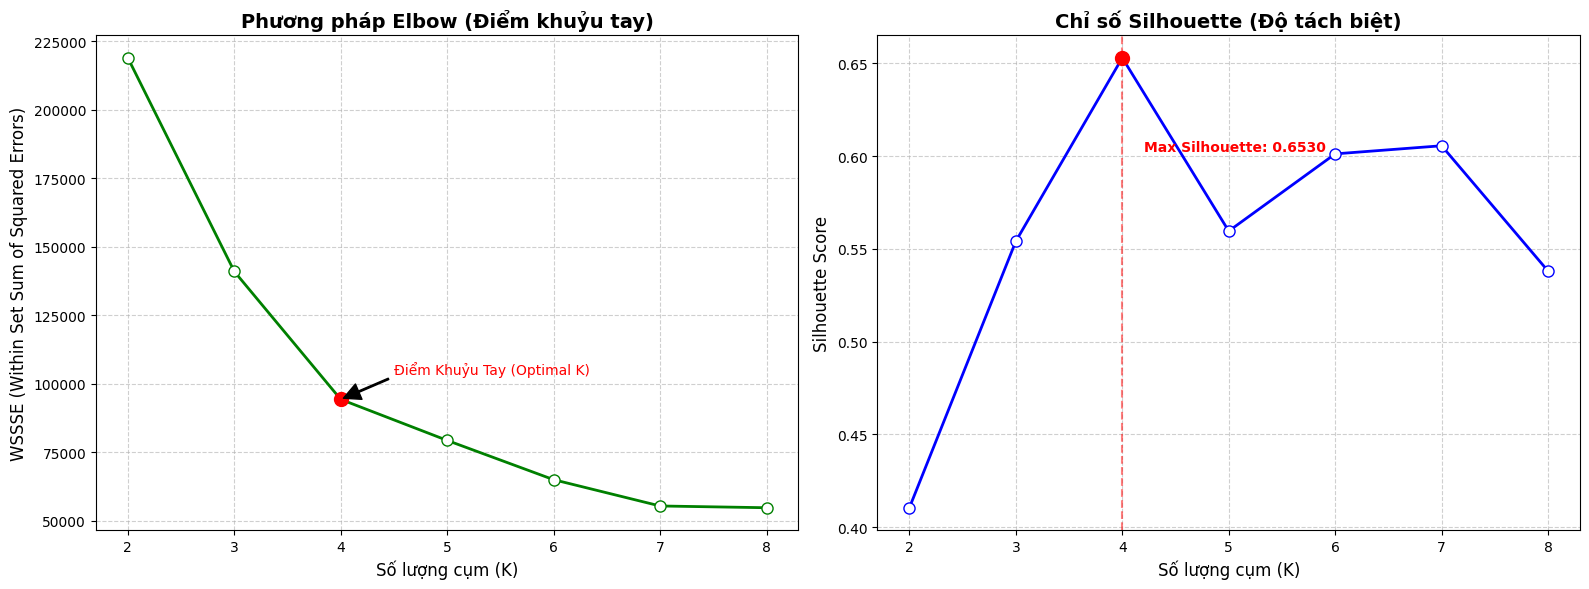


📊 Phân bố clusters (K-Means):
+----------+-----+------+-----+-------+
|prediction|count| avg_R|avg_F|  avg_M|
+----------+-----+------+-----+-------+
|         0|52015|177.98|  1.0| 134.72|
|         1|38053|438.42|  1.0| 134.25|
|         2| 2470|288.95| 1.01|1172.23|
|         3| 2881|270.09| 2.11| 289.62|
+----------+-----+------+-----+-------+


--- 10.2 Bisecting K-Means ---
   Bisecting K-Means (K=4): Silhouette=0.5600

📊 Phân bố clusters (Bisecting K-Means):
+----------+-----+------+-----+------+
|prediction|count| avg_R|avg_F| avg_M|
+----------+-----+------+-----+------+
|         0|52898|176.76|  1.0|162.19|
|         1| 2156|200.36| 2.13|336.09|
|         2|38185|436.31|  1.0|128.62|
|         3| 2180|454.07| 1.37| 748.1|
+----------+-----+------+-----+------+


--- 10.3 Gaussian Mixture Model ---
   GMM (K=4): Silhouette=0.7502

📊 Phân bố clusters (GMM):
+----------+-----+------+-----+-------+
|prediction|count| avg_R|avg_F|  avg_M|
+----------+-----+------+-----+-------+


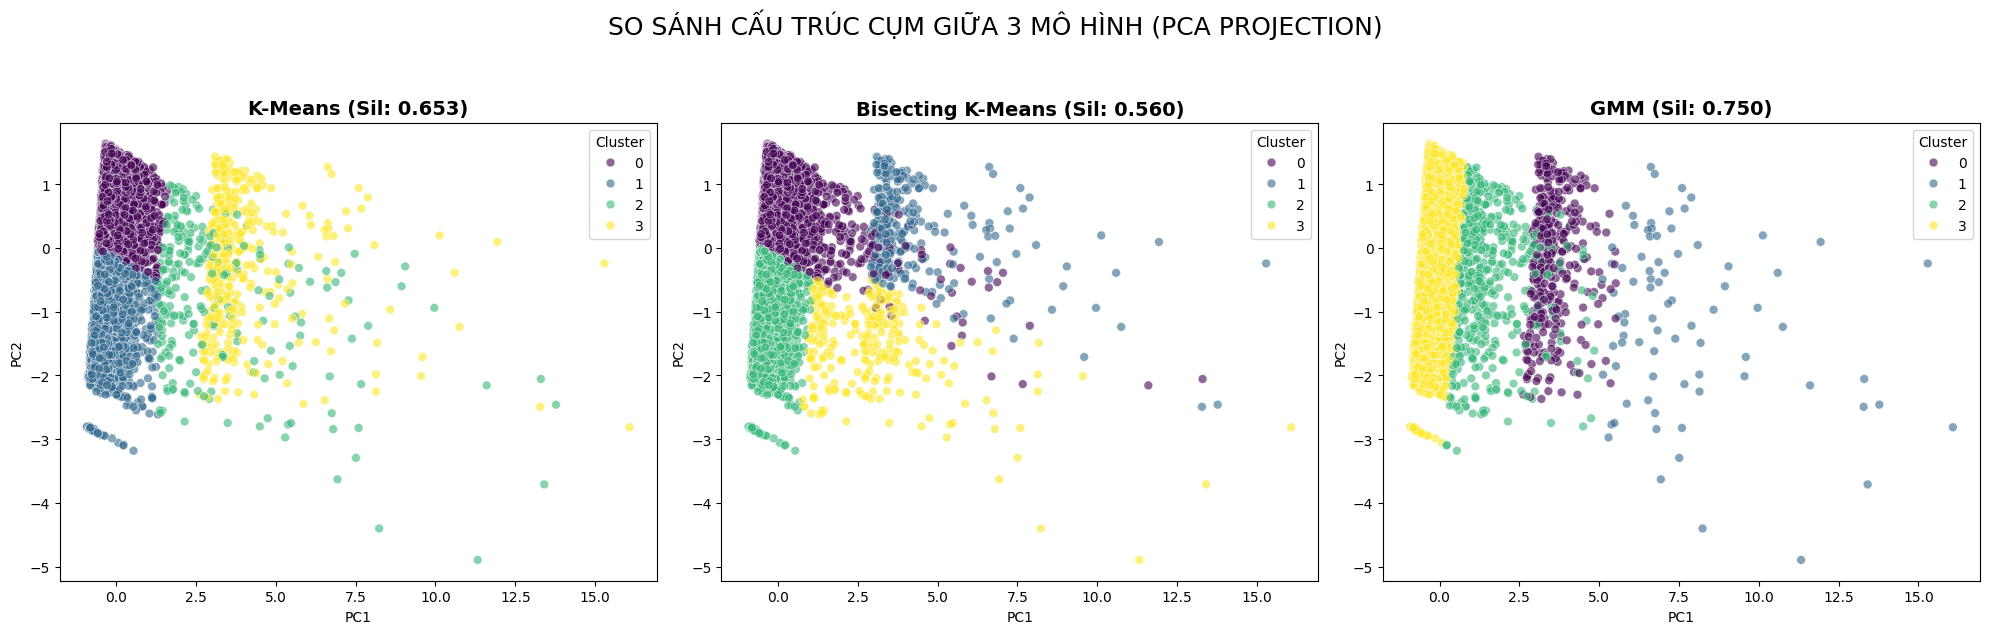


🎯 PHẦN 11: RECOMMENDATION - ALS (Pipeline End-to-End)
✅ ALS raw data: 97,916 ratings
   ALS train: 78,546 | test: 19,370
🔄 Training ALS Pipeline...
✅ ALS Pipeline RMSE: 4.0514 | Time: 70.6s

   Unique customers: 94,720
   Unique products : 31,724

🎁 Top 10 sản phẩm khuyến nghị cho 3 khách hàng mẫu:
+------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|customer_idx|recommendations                                                                                                                                                                                  |
+------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|65790       |[{693, 4.890677}, {9044, 4.604569}, {22672, 4.4945836}, {4

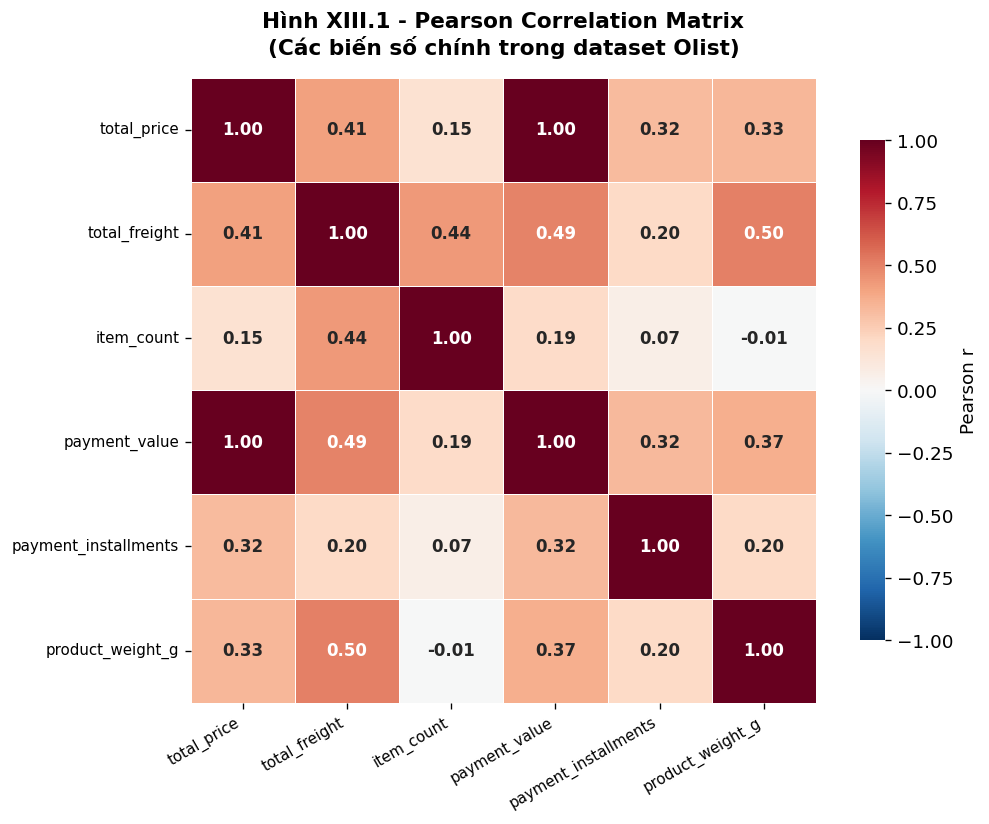

✅ Lưu fig_XIII1_correlation_heatmap.png

📊 13.3 Phân bố Label (Classification target):
+-----+-----+-----+
|label|count|  pct|
+-----+-----+-----+
|  0.0|22716|23.02|
|  1.0|75949|76.98|
+-----+-----+-----+



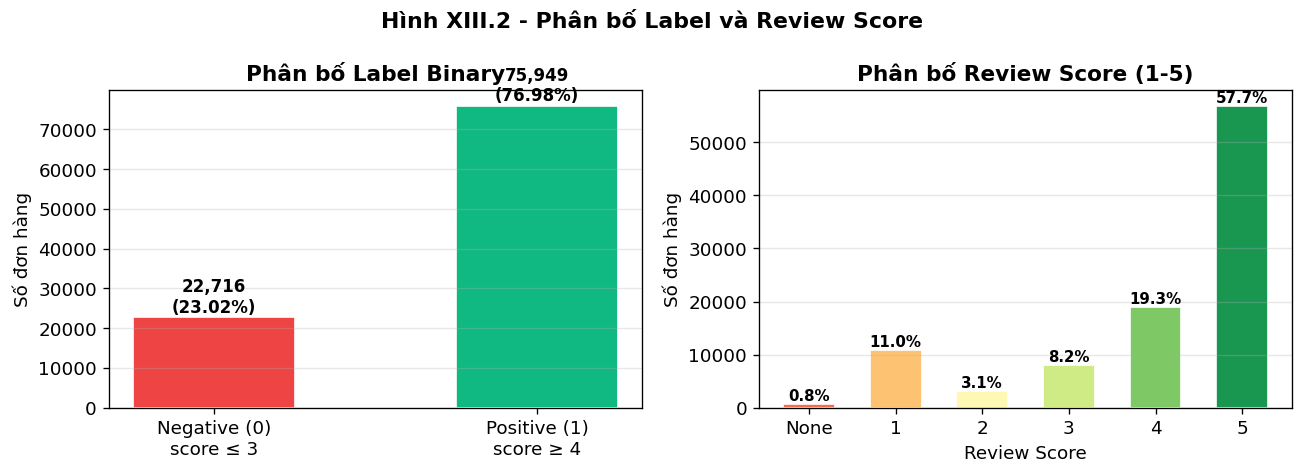

✅ Lưu fig_XIII2_label_distribution.png

📋 13.4 Bảng tổng hợp Classification metrics:
              model  accuracy  precision  recall     f1    auc  train_time
Logistic Regression    0.7737     0.7027  0.7737 0.6827 0.6077       17.73
      Random Forest    0.7745     0.5999  0.7745 0.6761 0.6105       46.07
        Naive Bayes    0.7745     0.7098  0.7745 0.6777 0.5165       10.71
          LinearSVC    0.7745     0.7127  0.7745 0.6762 0.5486       42.51
      GBTClassifier    0.7749     0.7183  0.7749 0.6887 0.6223      101.10

🏆 Best model (F1): GBTClassifier (F1=0.6887, AUC=0.6223)


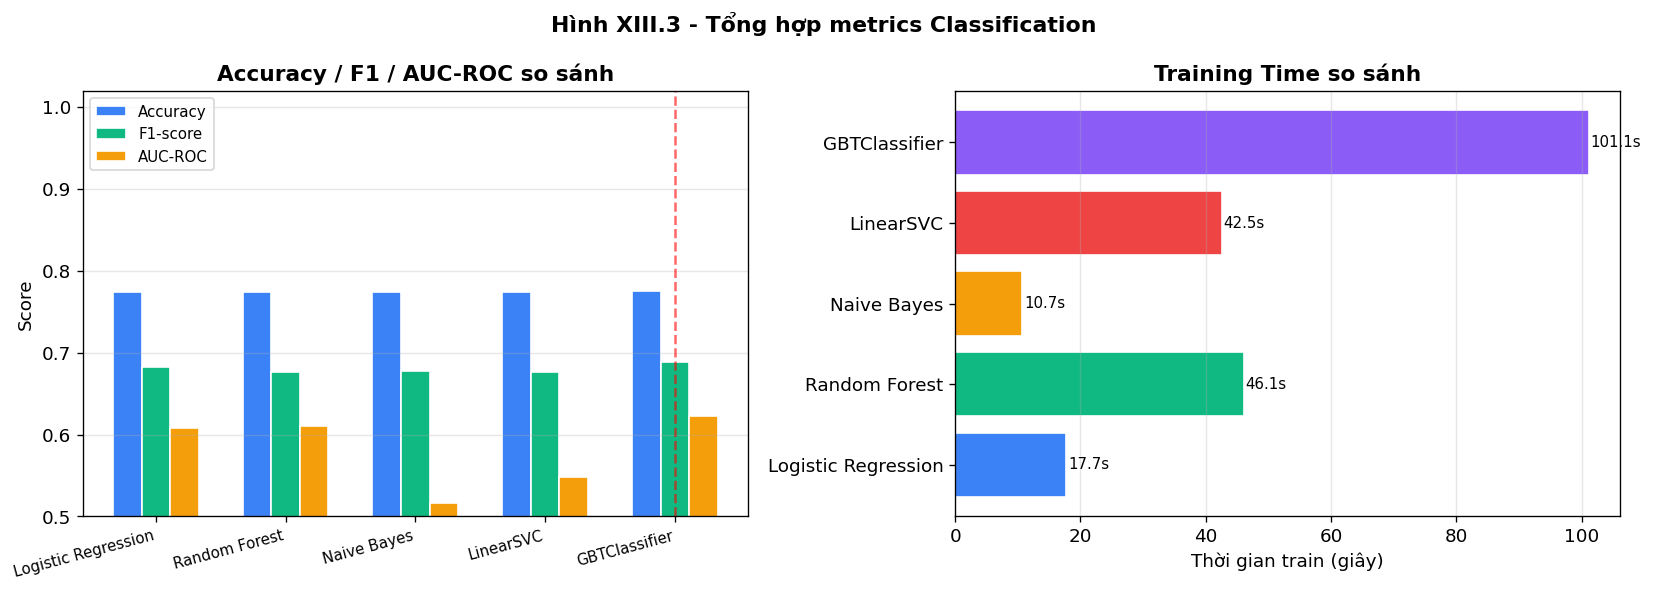

✅ Lưu fig_XIII3_clf_summary.png

📋 13.5 Bảng tổng hợp Regression metrics:
                  model     rmse     mae     r2  train_time
      Linear Regression 175.0504 84.3968 0.3481       13.18
Decision Tree Regressor 177.9817 81.4632 0.3261       13.01
Random Forest Regressor 169.9044 79.0357 0.3859       71.91

🏆 Best model (R²): Random Forest Regressor (R²=0.3859, RMSE=169.9044)


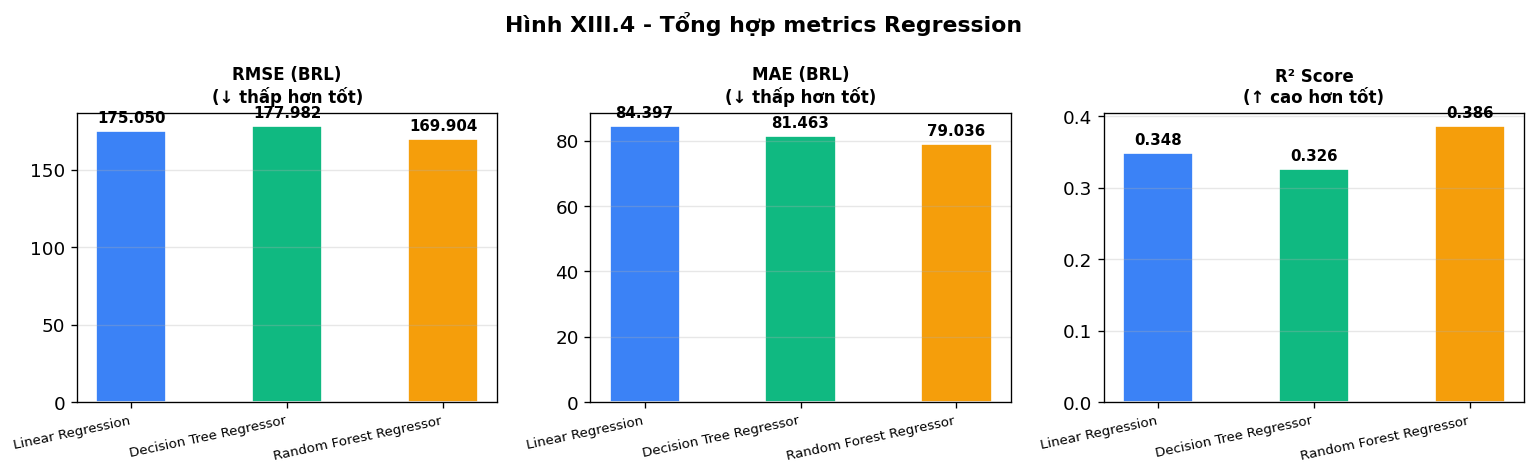

✅ Lưu fig_XIII4_reg_summary.png

🔢 13.6 Confusion Matrix (GBTClassifier):
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  137|
|  0.0|       1.0| 4261|
|  1.0|       0.0|  131|
|  1.0|       1.0|14978|
+-----+----------+-----+



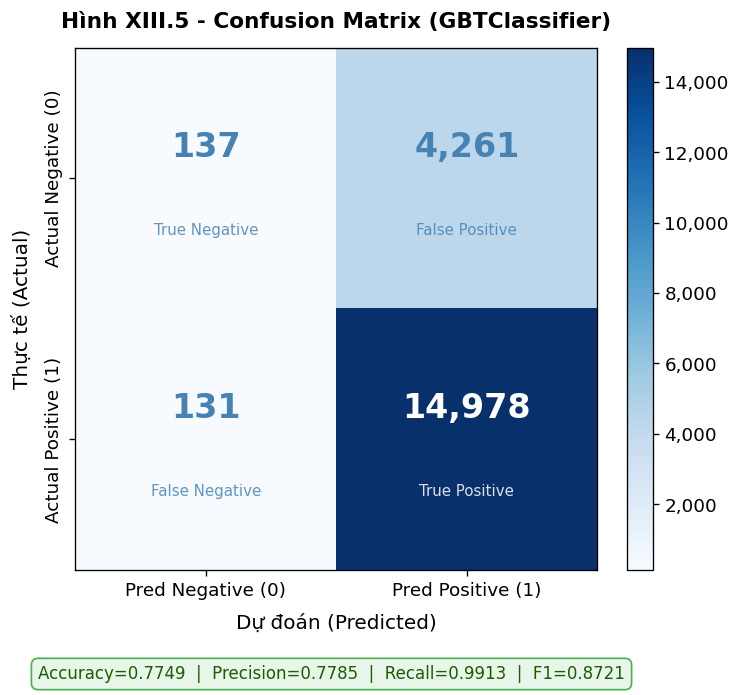

✅ Lưu fig_XIII5_confusion_matrix.png
   Accuracy=0.7749 | Precision=0.7785 | Recall=0.9913 | F1=0.8721

📋 TỔNG KẾT PHẦN 13

Thống kê mô tả:
   ✅ Describe() các biến số chính
   ✅ Median & IQR (percentile)
   ✅ Pearson Correlation Matrix + Heatmap

Classification:
   ✅ Bảng so sánh 5 model (Accuracy/F1/AUC/Time)
   ✅ Best model: GBTClassifier
   ✅ Confusion Matrix (GBT)

Regression:
   ✅ Bảng so sánh 3 model (RMSE/MAE/R²)
   ✅ Best model: Random Forest Regressor

Biểu đồ đã lưu:
   fig_XIII1_correlation_heatmap.png
   fig_XIII2_label_distribution.png
   fig_XIII3_clf_summary.png
   fig_XIII4_reg_summary.png
   fig_XIII5_confusion_matrix.png



In [11]:
# ============================================================
# ĐỒ ÁN CUỐI KỲ - BIG DATA ANALYTICS & MACHINE LEARNING
# Dataset: Brazilian E-Commerce (Olist) - ~100K orders, 9 CSV files
# Công nghệ: PySpark 3.x, MLlib, Streamlit, Plotly
# ============================================================

# ==================== 0. SETUP & KHỞI TẠO SPARK ====================
import os
import time
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, count, when, isnan, lit, datediff,
    max as spark_max, min as spark_min,
    sum as spark_sum, avg, stddev,
    year, month, dayofweek, to_date,
    regexp_replace, trim, lower
)
from pyspark.sql.types import *
from pyspark.sql.window import Window

# Stop existing SparkSession if running to ensure file system refresh
if 'spark' in globals():
    spark.stop()

# Tạo SparkSession
spark = SparkSession.builder \
    .appName("BigData_Olist_Analytics") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("✅ SparkSession khởi tạo thành công!")
print(f"   Spark version: {spark.version}")

# ==================== 1. ĐỌC DỮ LIỆU ====================
DATA_PATH = "/content/"  # Thư mục chứa 9 file CSV của Olist

def read_csv(filename):
    return spark.read.csv(
        DATA_PATH + filename,
        header=True,
        inferSchema=True
    )

print("\n📂 Đọc 9 file CSV từ dataset Olist...")
df_orders     = read_csv("olist_orders_dataset.csv")
df_items      = read_csv("olist_order_items_dataset.csv")
df_customers  = read_csv("olist_customers_dataset.csv")
df_products   = read_csv("olist_products_dataset.csv")
df_reviews    = read_csv("olist_order_reviews_dataset.csv")
df_sellers    = read_csv("olist_sellers_dataset.csv")
df_payments   = read_csv("olist_order_payments_dataset.csv")
df_geo        = read_csv("olist_geolocation_dataset.csv")
df_cat_trans  = read_csv("product_category_name_translation.csv")

print("✅ Đọc dữ liệu thành công!")

# ==================== 2. EDA - KHẢO SÁT DỮ LIỆU ====================
print("\n" + "="*60)
print("📊 PHẦN 2: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

datasets = {
    "orders": df_orders,
    "items": df_items,
    "customers": df_customers,
    "products": df_products,
    "reviews": df_reviews,
    "sellers": df_sellers,
    "payments": df_payments,
    "geolocation": df_geo,
    "category_translation": df_cat_trans
}

print("\n📋 Tổng quan các bảng dữ liệu:")
print(f"{'Bảng':<25} {'Số dòng':>10} {'Số cột':>8}")
print("-" * 45)
for name, df in datasets.items():
    print(f"{name:<25} {df.count():>10,} {len(df.columns):>8}")

# Schema của bảng chính
print("\n📐 Schema bảng orders:")
df_orders.printSchema()

print("\n📐 Schema bảng items:")
df_items.printSchema()

# Thống kê mô tả
print("\n📊 Thống kê mô tả bảng payments:")
df_payments.describe().show()

print("\n📊 Thống kê mô tả bảng reviews:")
df_reviews.select("review_score").describe().show()

# Kiểm tra missing values
print("\n🔍 Missing values trong bảng orders:")
df_orders.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_orders.columns
]).show()

print("\n🔍 Missing values trong bảng reviews:")
df_reviews.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_reviews.columns
]).show()

# Phân bố review_score
print("\n⭐ Phân bố review_score:")
df_reviews.groupBy("review_score") \
    .count() \
    .orderBy("review_score") \
    .withColumn("pct", F.round(col("count") / df_reviews.count() * 100, 2)) \
    .show()

# Phân bố phương thức thanh toán
print("\n💳 Phân bố phương thức thanh toán:")
df_payments.groupBy("payment_type") \
    .agg(count("*").alias("count"), F.round(avg("payment_value"), 2).alias("avg_value")) \
    .orderBy(col("count").desc()) \
    .show()

# Phân bố trạng thái đơn hàng
print("\n📦 Phân bố trạng thái đơn hàng:")
df_orders.groupBy("order_status").count().orderBy(col("count").desc()).show()

# Top 10 danh mục sản phẩm bán chạy
print("\n🏆 Top 10 danh mục sản phẩm:")
df_items.join(df_products, "product_id", "left") \
    .join(df_cat_trans, "product_category_name", "left") \
    .groupBy("product_category_name_english") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10) \
    .show()

# ==================== 3. JOIN VÀ TIỀN XỬ LÝ ====================
print("\n" + "="*60)
print("🔗 PHẦN 3: JOIN 9 BẢNG VÀ TIỀN XỬ LÝ DỮ LIỆU")
print("="*60)

# 3.1 Deduplicate geolocation theo zip_code_prefix
df_geo_dedup = df_geo.groupBy("geolocation_zip_code_prefix") \
    .agg(
        avg("geolocation_lat").alias("lat"),
        avg("geolocation_lng").alias("lng"),
        F.first("geolocation_city").alias("city"),
        F.first("geolocation_state").alias("state")
    )

# 3.2 Xử lý payments: tổng hợp theo order_id (1 order có thể có nhiều lần thanh toán)
df_payments_agg = df_payments.groupBy("order_id") \
    .agg(
        spark_sum("payment_value").alias("payment_value"),
        spark_sum("payment_installments").alias("payment_installments"),
        F.first("payment_type").alias("payment_type"),
        count("*").alias("payment_count")
    )

# 3.3 Xử lý reviews: lấy đánh giá mới nhất theo order_id
window_review = Window.partitionBy("order_id").orderBy(col("review_creation_date").desc())
df_reviews_dedup = df_reviews \
    .withColumn("rn", F.row_number().over(window_review)) \
    .filter(col("rn") == 1) \
    .drop("rn")

# 3.4 Xử lý items: tổng hợp theo order_id
df_items_agg = df_items.groupBy("order_id") \
    .agg(
        spark_sum("price").alias("total_price"),
        spark_sum("freight_value").alias("total_freight"),
        count("*").alias("item_count"),
        F.first("product_id").alias("product_id"),
        F.first("seller_id").alias("seller_id")
    )

# 3.5 JOIN tất cả bảng
print("🔗 Đang join 9 bảng...")
master_df = df_orders \
    .join(df_items_agg, "order_id", "inner") \
    .join(df_products, "product_id", "left") \
    .join(df_cat_trans, "product_category_name", "left") \
    .join(df_customers, "customer_id", "left") \
    .join(df_payments_agg, "order_id", "left") \
    .join(df_reviews_dedup.select(
        "order_id", "review_score", "review_comment_message"
    ), "order_id", "left") \
    .join(df_sellers.select(
        "seller_id", "seller_city", "seller_state"
    ), "seller_id", "left")

print(f"✅ Master DataFrame: {master_df.count():,} dòng × {len(master_df.columns)} cột")

# 3.6 Xử lý missing values
print("\n🧹 Xử lý missing values...")

master_df = master_df \
    .fillna("unknown", subset=["product_category_name", "product_category_name_english",
                                "payment_type", "seller_state", "seller_city"]) \
    .fillna("", subset=["review_comment_message"]) \
    .fillna(0, subset=["review_score", "product_weight_g", "product_length_cm",
                        "product_height_cm", "product_width_cm",
                        "product_photos_qty", "product_description_lenght",
                        "product_name_lenght"]) \
    .na.drop(subset=["order_purchase_timestamp", "payment_value",
                     "customer_unique_id", "order_id"])

# 3.7 Feature engineering từ timestamp
master_df = master_df \
    .withColumn("purchase_date", to_date(col("order_purchase_timestamp"))) \
    .withColumn("purchase_year", year(col("order_purchase_timestamp"))) \
    .withColumn("purchase_month", month(col("order_purchase_timestamp"))) \
    .withColumn("purchase_dow", dayofweek(col("order_purchase_timestamp"))) \
    .withColumn("delivery_days",
        when(col("order_delivered_customer_date").isNotNull(),
             datediff(col("order_delivered_customer_date"),
                      col("order_purchase_timestamp"))
        ).otherwise(lit(None))
    )

# 3.8 Tạo binary label cho classification: 1 = satisfied (score >= 4), 0 = not
master_df = master_df \
    .withColumn("label", when(col("review_score") >= 4, 1.0).otherwise(0.0))

master_df.cache()
print(f"✅ Sau tiền xử lý: {master_df.count():,} dòng × {len(master_df.columns)} cột")
print(f"   Phân bố label: ")
master_df.groupBy("label").count().orderBy("label").show()

# ==================== 4. RFM ANALYSIS ====================
print("\n" + "="*60)
print("📐 PHẦN 4: FEATURE ENGINEERING - RFM ANALYSIS")
print("="*60)

REF_DATE = "2018-10-17"  # Ngày tham chiếu (1 ngày sau ngày mua cuối cùng trong dataset)

rfm_df = master_df.groupBy("customer_unique_id") \
    .agg(
        datediff(lit(REF_DATE), spark_max("purchase_date")).alias("Recency"),
        count("order_id").alias("Frequency"),
        spark_sum("payment_value").alias("Monetary")
    )

print("📊 Thống kê RFM:")
rfm_df.describe().show()

# Chuẩn hóa RFM để clustering
from pyspark.ml.feature import VectorAssembler, StandardScaler

rfm_assembler = VectorAssembler(
    inputCols=["Recency", "Frequency", "Monetary"],
    outputCol="rfm_features"
)
rfm_df = rfm_assembler.transform(rfm_df)

rfm_scaler = StandardScaler(
    inputCol="rfm_features",
    outputCol="rfm_scaled",
    withMean=True, withStd=True
)
rfm_scaler_model = rfm_scaler.fit(rfm_df)
rfm_df = rfm_scaler_model.transform(rfm_df)
rfm_df.cache()
print(f"✅ RFM DataFrame: {rfm_df.count():,} khách hàng")

# ==================== 5. TF-IDF TRÊN REVIEW TEXT ====================
print("\n" + "="*60)
print("📝 PHẦN 5: TF-IDF TRÊN REVIEW COMMENT")
print("="*60)

from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF

# Stop words tiếng Bồ Đào Nha cơ bản
pt_stopwords = [
    "de", "a", "o", "que", "e", "do", "da", "em", "um", "para",
    "com", "uma", "os", "no", "se", "na", "por", "mais", "as", "dos",
    "como", "mas", "ao", "ele", "das", "à", "seu", "sua", "ou", "quando",
    "muito", "nos", "já", "eu", "também", "só", "pelo", "pela", "até",
    "isso", "ela", "entre", "depois", "sem", "mesmo", "aos", "durante",
    "nem", "nas", "meu", "nao", "không", "foi", "está", "era", "bem",
    "boa", "bom", "produto", "compra", "pedido", "entrega", "recebi"
]

review_df = master_df.select("order_id", "review_comment_message") \
    .withColumn("review_clean",
        lower(regexp_replace(col("review_comment_message"), r"[^a-zA-ZÀ-ÿ\s]", " "))
    )

tokenizer = Tokenizer(inputCol="review_clean", outputCol="tokens")
review_df = tokenizer.transform(review_df)

remover = StopWordsRemover(
    inputCol="tokens", outputCol="filtered_tokens",
    stopWords=pt_stopwords
)
review_df = remover.transform(review_df)

cv = CountVectorizer(
    inputCol="filtered_tokens", outputCol="tf",
    vocabSize=5000, minDF=5.0
)
cv_model = cv.fit(review_df)
review_df = cv_model.transform(review_df)

idf = IDF(inputCol="tf", outputCol="tfidf")
idf_model = idf.fit(review_df)
review_df = idf_model.transform(review_df)

print(f"✅ TF-IDF vocab size: {len(cv_model.vocabulary)}")
print(f"   Top 10 terms: {cv_model.vocabulary[:10]}")

# ==================== 6. SPARK ML PIPELINE ====================
print("\n" + "="*60)
print("⚙️ PHẦN 6: XÂY DỰNG SPARK ML PIPELINE")
print("="*60)

import time
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, VarianceThresholdSelector
)

# ── 6.1 Định nghĩa columns ──────────────────────────────────
cat_cols = ["product_category_name_english", "payment_type",
            "customer_state", "seller_state", "purchase_month"]

num_cols = ["total_price", "total_freight", "item_count",
            "payment_value", "payment_installments",
            "product_weight_g", "product_photos_qty",
            "purchase_year", "purchase_dow",
            "product_name_lenght", "product_description_lenght"]

# Lọc chỉ giữ cột thực sự tồn tại trong master_df
existing_cols = master_df.columns
cat_cols = [c for c in cat_cols if c in existing_cols]
num_cols = [c for c in num_cols if c in existing_cols]
print(f"✅ cat_cols ({len(cat_cols)}): {cat_cols}")
print(f"✅ num_cols ({len(num_cols)}): {num_cols}")

# ── 6.2 Tiền xử lý master_df ───────────────────────────────
# Cast sang string cho StringIndexer
for c in cat_cols:
    master_df = master_df.withColumn(c, F.col(c).cast("string"))

master_df = master_df.fillna("unknown", subset=cat_cols)
master_df = master_df.fillna(0.0,       subset=num_cols)

# Tạo label nếu chưa có
if "label" not in master_df.columns:
    master_df = master_df.withColumn(
        "label", F.when(F.col("review_score") >= 4, 1.0).otherwise(0.0)
    )

# Bỏ dòng null ở label và cột quan trọng
master_df = master_df.na.drop(subset=["label", "payment_value"])
print(f"✅ master_df: {master_df.count():,} dòng sau tiền xử lý")

# ── 6.3 Train / Test split ──────────────────────────────────
train_df, test_df = master_df.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.cache()
test_df  = test_df.cache()
print(f"✅ Train: {train_df.count():,} | Test: {test_df.count():,}")
train_df.groupBy("label").count().orderBy("label").show()

# ── 6.4 Xây dựng Pipeline stages ────────────────────────────
indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in cat_cols
]

encoders = [
    OneHotEncoder(inputCols=[c+"_idx"], outputCols=[c+"_ohe"], handleInvalid="keep")
    for c in cat_cols
]

ohe_cols = [c+"_ohe" for c in cat_cols]

assembler = VectorAssembler(
    inputCols=num_cols + ohe_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=False,   # False để tránh lỗi với sparse vector OHE
    withStd=True
)

# ── THAY ChiSqSelector bằng VarianceThresholdSelector ──────
# ChiSqSelector chỉ dùng được với categorical label,
# không dùng được với continuous numeric features (>10000 distinct)
# VarianceThresholdSelector: loại bỏ features có variance thấp (gần constant)
var_selector = VarianceThresholdSelector(
    featuresCol="features_scaled",
    outputCol="features",
    varianceThreshold=0.0   # loại features có variance = 0 (constant hoàn toàn)
)

feature_pipeline = Pipeline(
    stages=indexers + encoders + [assembler, scaler, var_selector]
)

# ── 6.5 Fit và Transform ────────────────────────────────────
print("\n🔄 Fitting feature pipeline...")
feature_pipeline_model = feature_pipeline.fit(train_df)
train_features = feature_pipeline_model.transform(train_df).cache()
test_features  = feature_pipeline_model.transform(test_df).cache()

print("✅ Pipeline fit xong!")
print(f"   train_features: {train_features.count():,}")
print(f"   test_features : {test_features.count():,}")
train_features.select("features", "label").printSchema()

# Kiểm tra số features sau selector
sample_vec = train_features.select("features").first()[0]
print(f"   Số features sau VarianceThresholdSelector: {len(sample_vec)}")

# ==================== 7. CLASSIFICATION (5 MÔ HÌNH) ====================
print("\n" + "="*60)
print("🤖 PHẦN 7: CLASSIFICATION - 5 MÔ HÌNH")
print("="*60)

import time
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, ChiSqSelector, MinMaxScaler
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier,
    NaiveBayes, LinearSVC, GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)

# ── GUARD: Nếu train_features chưa tồn tại thì tạo lại ─────
try:
    train_features
    test_features
    print("✅ train_features / test_features đã sẵn sàng")
except NameError:
    print("⚠️  train_features chưa có → đang tạo lại từ master_df...")

    cat_cols = ["product_category_name_english", "payment_type",
                "customer_state", "seller_state", "purchase_month"]
    num_cols = ["total_price", "total_freight", "item_count",
                "payment_value", "payment_installments",
                "product_weight_g", "product_photos_qty",
                "purchase_year", "purchase_dow",
                "product_name_lenght", "product_description_lenght"]

    # Lọc chỉ lấy cột thực sự tồn tại
    existing = master_df.columns
    cat_cols = [c for c in cat_cols if c in existing]
    num_cols = [c for c in num_cols if c in existing]

    # Tiền xử lý
    for c in cat_cols:
        master_df = master_df.withColumn(c, F.col(c).cast("string"))
    master_df = master_df.fillna("unknown", subset=cat_cols)
    master_df = master_df.fillna(0.0, subset=num_cols)

    if "label" not in master_df.columns:
        master_df = master_df.withColumn(
            "label", F.when(F.col("review_score") >= 4, 1.0).otherwise(0.0)
        )
    master_df = master_df.na.drop(subset=["label", "payment_value"])

    # Split
    train_df, test_df = master_df.randomSplit([0.8, 0.2], seed=42)
    train_df = train_df.cache()
    test_df  = test_df.cache()
    print(f"   Train: {train_df.count():,} | Test: {test_df.count():,}")

    # Build & fit pipeline
    indexers_g = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
                  for c in cat_cols]
    encoders_g = [OneHotEncoder(inputCols=[c+"_idx"], outputCols=[c+"_ohe"], handleInvalid="keep")
                  for c in cat_cols]
    ohe_cols   = [c+"_ohe" for c in cat_cols]

    assembler_g = VectorAssembler(inputCols=num_cols+ohe_cols,
                                  outputCol="features_raw", handleInvalid="skip")
    scaler_g    = StandardScaler(inputCol="features_raw", outputCol="features_scaled",
                                  withMean=False, withStd=True)
    selector_g  = ChiSqSelector(numTopFeatures=40, featuresCol="features_scaled",
                                 outputCol="features", labelCol="label")

    feature_pipeline = Pipeline(stages=indexers_g + encoders_g +
                                        [assembler_g, scaler_g, selector_g])
    feature_pipeline_model = feature_pipeline.fit(train_df)
    train_features = feature_pipeline_model.transform(train_df).cache()
    test_features  = feature_pipeline_model.transform(test_df).cache()

    # Lưu lại để NB dùng
    indexers = indexers_g
    encoders = encoders_g

    print(f"✅ Tạo lại xong! train_features: {train_features.count():,}")

# ── Đảm bảo cat_cols / num_cols / ohe_cols / indexers / encoders tồn tại ──
try:
    cat_cols; num_cols; ohe_cols; indexers; encoders
except NameError:
    cat_cols = ["product_category_name_english", "payment_type",
                "customer_state", "seller_state", "purchase_month"]
    num_cols = ["total_price", "total_freight", "item_count",
                "payment_value", "payment_installments",
                "product_weight_g", "product_photos_qty",
                "purchase_year", "purchase_dow",
                "product_name_lenght", "product_description_lenght"]
    existing = master_df.columns
    cat_cols = [c for c in cat_cols if c in existing]
    num_cols = [c for c in num_cols if c in existing]
    ohe_cols = [c+"_ohe" for c in cat_cols]
    indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
                for c in cat_cols]
    encoders = [OneHotEncoder(inputCols=[c+"_idx"], outputCols=[c+"_ohe"], handleInvalid="keep")
                for c in cat_cols]

# ── Hàm đánh giá ────────────────────────────────────────────
def evaluate_classifier(model_name, predictions):
    binary_eval = BinaryClassificationEvaluator(labelCol="label")
    multi_eval  = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
    f1_eval     = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
    prec_eval   = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
    rec_eval    = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")

    # BinaryClassificationEvaluator cần cột rawPrediction / probability
    has_prob = "probability" in predictions.columns
    auc = binary_eval.evaluate(predictions) if has_prob else 0.0

    acc  = multi_eval.evaluate(predictions)
    f1   = f1_eval.evaluate(predictions)
    prec = prec_eval.evaluate(predictions)
    rec  = rec_eval.evaluate(predictions)

    print(f"\n📊 {model_name}:")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-score  : {f1:.4f}")
    if has_prob:
        print(f"   AUC-ROC   : {auc:.4f}")
    else:
        print(f"   AUC-ROC   : N/A (LinearSVC không có probability)")

    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc}

clf_results = []
trained_classifiers = {}

# ── 7.1 Logistic Regression ─────────────────────────────────
print("\n--- 7.1 Logistic Regression ---")
t0 = time.time()
lr = LogisticRegression(
    featuresCol="features", labelCol="label",
    maxIter=100, regParam=0.01, elasticNetParam=0.0,
    family="binomial"
)
lr_model  = lr.fit(train_features)
lr_preds  = lr_model.transform(test_features)
lr_time   = time.time() - t0
res = evaluate_classifier("Logistic Regression", lr_preds)
res["train_time"] = round(lr_time, 2)
clf_results.append(res)
trained_classifiers["LogisticRegression"] = lr_model

# ── 7.2 Random Forest ───────────────────────────────────────
print("\n--- 7.2 Random Forest Classifier ---")
t0 = time.time()
rf = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    numTrees=100, maxDepth=8, seed=42,
    featureSubsetStrategy="sqrt"
)
rf_model = rf.fit(train_features)
rf_preds = rf_model.transform(test_features)
rf_time  = time.time() - t0
res = evaluate_classifier("Random Forest", rf_preds)
res["train_time"] = round(rf_time, 2)
clf_results.append(res)
trained_classifiers["RandomForest"] = rf_model

print("   🔑 Top 10 Feature Importances (RF):")
importances = rf_model.featureImportances
top_idx = sorted(range(len(importances)), key=lambda i: importances[i], reverse=True)[:10]
for idx in top_idx:
    print(f"     Feature[{idx}]: {importances[idx]:.4f}")

# ── 7.3 Naive Bayes ─────────────────────────────────────────
print("\n--- 7.3 Naive Bayes ---")
# NB cần features >= 0 → dùng MinMaxScaler riêng
nb_assembler = VectorAssembler(
    inputCols=num_cols + ohe_cols,
    outputCol="features_raw_nb",
    handleInvalid="skip"
)
nb_scaler = MinMaxScaler(inputCol="features_raw_nb", outputCol="features")

nb_prep_pipeline = Pipeline(stages=indexers + encoders + [nb_assembler, nb_scaler])
nb_prep_model    = nb_prep_pipeline.fit(train_df)
train_nb = nb_prep_model.transform(train_df).cache()
test_nb  = nb_prep_model.transform(test_df).cache()

t0 = time.time()
nb       = NaiveBayes(featuresCol="features", labelCol="label",
                      smoothing=1.0, modelType="multinomial")
nb_model = nb.fit(train_nb)
nb_preds = nb_model.transform(test_nb)
nb_time  = time.time() - t0
res = evaluate_classifier("Naive Bayes", nb_preds)
res["train_time"] = round(nb_time, 2)
clf_results.append(res)
trained_classifiers["NaiveBayes"] = nb_model

# ── 7.4 LinearSVC ───────────────────────────────────────────
# ── 7.4 LinearSVC (có AUC qua rawPrediction) ────────────────
print("\n--- 7.4 LinearSVC ---")
t0 = time.time()

from pyspark.ml.classification import LinearSVC
from pyspark.sql import functions as F

svc = LinearSVC(
    featuresCol="features", labelCol="label",
    maxIter=100, regParam=0.01
)
svc_model = svc.fit(train_features)
svc_preds = svc_model.transform(test_features)
svc_time  = time.time() - t0

# LinearSVC có rawPrediction dạng [score_class0, score_class1]
# Dùng score của class 1 (index 1) làm "probability" để tính AUC
from pyspark.ml.functions import vector_to_array

svc_preds_with_score = svc_preds.withColumn(
    "rawScore",
    vector_to_array(F.col("rawPrediction"))[1]   # lấy score của class 1
)

# Tính AUC dùng rawScore thay probability
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

svc_binary_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",   # dùng rawPrediction trực tiếp
    metricName="areaUnderROC"
)
svc_auc = svc_binary_eval.evaluate(svc_preds)

svc_acc  = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(svc_preds)
svc_f1   = MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(svc_preds)
svc_prec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision").evaluate(svc_preds)
svc_rec  = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall").evaluate(svc_preds)

print(f"\n📊 LinearSVC:")
print(f"   Accuracy  : {svc_acc:.4f}")
print(f"   Precision : {svc_prec:.4f}")
print(f"   Recall    : {svc_rec:.4f}")
print(f"   F1-score  : {svc_f1:.4f}")
print(f"   AUC-ROC   : {svc_auc:.4f}")   # ← có AUC rồi!
print(f"   Train time: {svc_time:.2f}s")

res = {
    "model": "LinearSVC",
    "accuracy": svc_acc, "precision": svc_prec,
    "recall": svc_rec, "f1": svc_f1,
    "auc": svc_auc,
    "train_time": round(svc_time, 2)
}
clf_results.append(res)
trained_classifiers["LinearSVC"] = svc_model

# ── 7.5 GBTClassifier ───────────────────────────────────────
print("\n--- 7.5 GBTClassifier ---")
t0 = time.time()
gbt       = GBTClassifier(featuresCol="features", labelCol="label",
                           maxIter=50, maxDepth=5, stepSize=0.1, seed=42)
gbt_model = gbt.fit(train_features)
gbt_preds = gbt_model.transform(test_features)
gbt_time  = time.time() - t0
res = evaluate_classifier("GBTClassifier", gbt_preds)
res["train_time"] = round(gbt_time, 2)
clf_results.append(res)
trained_classifiers["GBTClassifier"] = gbt_model

# ==================== 8. CROSS-VALIDATION & HYPERPARAMETER TUNING ====================
print("\n" + "="*60)
print("🔁 PHẦN 8: CROSS-VALIDATION & HYPERPARAMETER TUNING")
print("="*60)

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline
import time

cv_evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
cv_results = []

# ── 8.1 Cross-Validation cho Random Forest ──────────────────
print("\n--- 8.1 CrossValidator: Random Forest ---")

rf_cv = RandomForestClassifier(
    featuresCol="features", labelCol="label", seed=42
)

rf_param_grid = ParamGridBuilder() \
    .addGrid(rf_cv.numTrees, [50, 100]) \
    .addGrid(rf_cv.maxDepth, [5, 8]) \
    .build()

rf_crossval = CrossValidator(
    estimator=rf_cv,
    estimatorParamMaps=rf_param_grid,
    evaluator=cv_evaluator,
    numFolds=3,
    seed=42
)

t0 = time.time()
print("🔄 Training RF CrossValidator (3-fold × 4 combos = 12 fits)...")
rf_cv_model = rf_crossval.fit(train_features)
rf_cv_time = time.time() - t0

rf_cv_preds = rf_cv_model.transform(test_features)

# Đánh giá
rf_cv_auc  = cv_evaluator.evaluate(rf_cv_preds)
rf_cv_acc  = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(rf_cv_preds)
rf_cv_f1   = MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(rf_cv_preds)
rf_cv_prec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision").evaluate(rf_cv_preds)
rf_cv_rec  = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall").evaluate(rf_cv_preds)

print(f"\n📊 Random Forest (CV Best):")
print(f"  Accuracy  : {rf_cv_acc:.4f}")
print(f"  Precision : {rf_cv_prec:.4f}")
print(f"  Recall    : {rf_cv_rec:.4f}")
print(f"  F1-score  : {rf_cv_f1:.4f}")
print(f"  AUC-ROC   : {rf_cv_auc:.4f}")
print(f"  Train time: {rf_cv_time:.2f}s")

# In best params
best_rf = rf_cv_model.bestModel
print(f"\n  ✅ Best RF Params:")
print(f"     numTrees : {best_rf.getNumTrees}")
print(f"     maxDepth : {best_rf.getOrDefault('maxDepth')}")
print(f"  📊 Avg CV AUC per combo:")
for i, score in enumerate(rf_cv_model.avgMetrics):
    p = rf_param_grid[i]
    trees = p[rf_cv.numTrees]
    depth = p[rf_cv.maxDepth]
    print(f"     numTrees={trees}, maxDepth={depth} → AUC={score:.4f}")

cv_results.append({
    "model": "Random Forest (CV)",
    "accuracy": rf_cv_acc, "precision": rf_cv_prec,
    "recall": rf_cv_rec, "f1": rf_cv_f1,
    "auc": rf_cv_auc, "train_time": round(rf_cv_time, 2)
})

# ── 8.2 Cross-Validation cho GBTClassifier ──────────────────
print("\n--- 8.2 CrossValidator: GBTClassifier ---")

gbt_cv = GBTClassifier(
    featuresCol="features", labelCol="label", seed=42
)

gbt_param_grid = ParamGridBuilder() \
    .addGrid(gbt_cv.maxIter, [30, 50]) \
    .addGrid(gbt_cv.maxDepth, [4, 5]) \
    .addGrid(gbt_cv.stepSize, [0.05, 0.1]) \
    .build()

gbt_crossval = CrossValidator(
    estimator=gbt_cv,
    estimatorParamMaps=gbt_param_grid,
    evaluator=cv_evaluator,
    numFolds=3,
    seed=42
)

t0 = time.time()
print("🔄 Training GBT CrossValidator (3-fold × 8 combos = 24 fits)...")
gbt_cv_model = gbt_crossval.fit(train_features)
gbt_cv_time = time.time() - t0

gbt_cv_preds = gbt_cv_model.transform(test_features)

gbt_cv_auc  = cv_evaluator.evaluate(gbt_cv_preds)
gbt_cv_acc  = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(gbt_cv_preds)
gbt_cv_f1   = MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(gbt_cv_preds)
gbt_cv_prec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision").evaluate(gbt_cv_preds)
gbt_cv_rec  = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall").evaluate(gbt_cv_preds)

print(f"\n📊 GBTClassifier (CV Best):")
print(f"  Accuracy  : {gbt_cv_acc:.4f}")
print(f"  Precision : {gbt_cv_prec:.4f}")
print(f"  Recall    : {gbt_cv_rec:.4f}")
print(f"  F1-score  : {gbt_cv_f1:.4f}")
print(f"  AUC-ROC   : {gbt_cv_auc:.4f}")
print(f"  Train time: {gbt_cv_time:.2f}s")

best_gbt = gbt_cv_model.bestModel
print(f"\n  ✅ Best GBT Params:")
print(f"     maxIter  : {best_gbt.getOrDefault('maxIter')}")
print(f"     maxDepth : {best_gbt.getOrDefault('maxDepth')}")
print(f"     stepSize : {best_gbt.getOrDefault('stepSize')}")
print(f"  📊 Avg CV AUC per combo:")
for i, score in enumerate(gbt_cv_model.avgMetrics):
    p = gbt_param_grid[i]
    itr   = p[gbt_cv.maxIter]
    depth = p[gbt_cv.maxDepth]
    step  = p[gbt_cv.stepSize]
    print(f"     maxIter={itr}, maxDepth={depth}, stepSize={step} → AUC={score:.4f}")

cv_results.append({
    "model": "GBTClassifier (CV)",
    "accuracy": gbt_cv_acc, "precision": gbt_cv_prec,
    "recall": gbt_cv_rec, "f1": gbt_cv_f1,
    "auc": gbt_cv_auc, "train_time": round(gbt_cv_time, 2)
})

# ── 8.3 Bảng so sánh CV vs baseline ────────────────────────
print("\n" + "="*60)
print("📋 BẢNG SO SÁNH: BASELINE vs CROSS-VALIDATION")
print("="*60)

# Lấy baseline từ clf_results (phần 7)
baseline_rf  = next((r for r in clf_results if r["model"] == "Random Forest"), None)
baseline_gbt = next((r for r in clf_results if r["model"] == "GBTClassifier"), None)

print(f"\n{'Model':<28} {'Accuracy':>10} {'F1':>8} {'AUC':>8} {'Time(s)':>8}")
print("-" * 65)

if baseline_rf:
    print(f"{'Random Forest (Baseline)':<28} {baseline_rf['accuracy']:>10.4f} "
          f"{baseline_rf['f1']:>8.4f} {baseline_rf['auc']:>8.4f} {baseline_rf['train_time']:>8.2f}")
print(f"{'Random Forest (CV Best)':<28} {rf_cv_acc:>10.4f} "
      f"{rf_cv_f1:>8.4f} {rf_cv_auc:>8.4f} {rf_cv_time:>8.2f}")

print()

if baseline_gbt:
    print(f"{'GBTClassifier (Baseline)':<28} {baseline_gbt['accuracy']:>10.4f} "
          f"{baseline_gbt['f1']:>8.4f} {baseline_gbt['auc']:>8.4f} {baseline_gbt['train_time']:>8.2f}")
print(f"{'GBTClassifier (CV Best)':<28} {gbt_cv_acc:>10.4f} "
      f"{gbt_cv_f1:>8.4f} {gbt_cv_auc:>8.4f} {gbt_cv_time:>8.2f}")

# ── 8.4 Confusion Matrix best CV model ──────────────────────
print("\n🔢 Confusion Matrix (GBTClassifier CV Best):")
gbt_cv_preds.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

# Lưu reference để dùng ở phần 14
# best_rf  → rf_cv_model.bestModel
# best_gbt → gbt_cv_model.bestModel
print("\n✅ Cross-Validation hoàn tất!")
print(f"   best_rf  (numTrees={best_rf.getNumTrees}, maxDepth={best_rf.getOrDefault('maxDepth')})")
print(f"   best_gbt (maxIter={best_gbt.getOrDefault('maxIter')}, "
      f"maxDepth={best_gbt.getOrDefault('maxDepth')}, "
      f"stepSize={best_gbt.getOrDefault('stepSize')})")

# ==================== 8. HYPERPARAMETER TUNING (NHANH) ====================
print("\n" + "="*60)
print("🔧 PHẦN 8: HYPERPARAMETER TUNING")
print("="*60)

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import BinaryClassificationEvaluator

cv_eval = BinaryClassificationEvaluator(labelCol="label")


# ── 8.1 Tuning Random Forest (nhanh) ────────────────────────
# CrossValidator 3-fold nhưng grid nhỏ: 2×2 = 4 combos × 3 fold = 12 lần train
print("\n🔄 Tuning Random Forest (CV 3-fold, 4 combos)...")
t0 = time.time()

rf_for_tuning = RandomForestClassifier(
    featuresCol="features", labelCol="label", seed=42
)
rf_paramGrid = ParamGridBuilder() \
    .addGrid(rf_for_tuning.numTrees, [50, 100]) \
    .addGrid(rf_for_tuning.maxDepth, [5, 8]) \
    .build()  # 2×2 = 4 combinations

rf_cv = CrossValidator(
    estimator=rf_for_tuning,
    estimatorParamMaps=rf_paramGrid,
    evaluator=cv_eval,
    numFolds=3,
    seed=42,
    parallelism=2   # chạy song song 2 combo một lúc
)
rf_cv_model  = rf_cv.fit(train_features)
best_rf      = rf_cv_model.bestModel
rf_cv_preds  = rf_cv_model.transform(test_features)
rf_cv_auc    = cv_eval.evaluate(rf_cv_preds)
rf_tune_time = time.time() - t0

print(f"✅ Best RF: numTrees={best_rf.getNumTrees}, maxDepth={best_rf.getMaxDepth()}")
print(f"   AUC-ROC after tuning : {rf_cv_auc:.4f}")
print(f"   Thời gian tuning RF  : {rf_tune_time:.1f}s")

# ── 8.2 Tuning GBT — dùng TrainValidationSplit thay CrossValidator ──
# TrainValidationSplit: chỉ 1 lần split (80/20) thay vì 3-fold
# → nhanh gấp 3 lần so với CrossValidator
# Grid nhỏ: 2×2 = 4 combos × 1 split = 4 lần train GBT (thay vì 24)
print("\n🔄 Tuning GBT (TrainValidationSplit, 4 combos)...")
t0 = time.time()

gbt_for_tuning = GBTClassifier(
    featuresCol="features", labelCol="label",
    seed=42,
    maxIter=30       # giảm từ 50 → 30 để nhanh hơn
)
gbt_paramGrid = ParamGridBuilder() \
    .addGrid(gbt_for_tuning.stepSize, [0.05, 0.1]) \
    .addGrid(gbt_for_tuning.maxDepth, [4, 5]) \
    .build()  # 2×2 = 4 combinations

gbt_tvs = TrainValidationSplit(
    estimator=gbt_for_tuning,
    estimatorParamMaps=gbt_paramGrid,
    evaluator=cv_eval,
    trainRatio=0.8,  # 80% train, 20% validation
    seed=42,
    parallelism=2    # chạy song song 2 combo một lúc
)
gbt_tvs_model  = gbt_tvs.fit(train_features)
best_gbt       = gbt_tvs_model.bestModel
gbt_tvs_preds  = gbt_tvs_model.transform(test_features)
gbt_tvs_auc    = cv_eval.evaluate(gbt_tvs_preds)
gbt_tune_time  = time.time() - t0

print(f"✅ Best GBT: maxIter={best_gbt.getMaxIter()}, "
      f"stepSize={best_gbt.getStepSize()}, maxDepth={best_gbt.getMaxDepth()}")
print(f"   AUC-ROC after tuning : {gbt_tvs_auc:.4f}")
print(f"   Thời gian tuning GBT : {gbt_tune_time:.1f}s")

# ── Tổng kết ────────────────────────────────────────────────
print("\n📋 Tổng kết Tuning:")
print(f"{'Model':<20} {'Method':<22} {'Combos':>7} {'AUC':>8} {'Time(s)':>8}")
print("-" * 70)
print(f"{'Random Forest':<20} {'CrossValidator 3-fold':<22} {4:>7} {rf_cv_auc:>8.4f} {rf_tune_time:>8.1f}")
print(f"{'GBTClassifier':<20} {'TrainValidationSplit':<22} {4:>7} {gbt_tvs_auc:>8.4f} {gbt_tune_time:>8.1f}")
# ── Bảng tổng hợp ───────────────────────────────────────────
print("\n" + "="*60)
print("📋 BẢNG SO SÁNH CLASSIFICATION:")
print("="*60)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'AUC':>8} {'Time(s)':>8}")
print("-" * 80)
for r in clf_results:
    print(f"{r['model']:<22} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>8.4f} {r['f1']:>8.4f} {r['auc']:>8.4f} {r['train_time']:>8.2f}")

# Confusion matrix - model tốt nhất (GBT)
print("\n🔢 Confusion Matrix (GBTClassifier):")
gbt_preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Số liệu thực tế từ Spark output ─────────────────────────
# gbt_cv_preds.groupBy("label","prediction").count().orderBy("label","prediction").show()
# label=0, pred=0 → TN | label=0, pred=1 → FP
# label=1, pred=0 → FN | label=1, pred=1 → TP

tn, fp, fn, tp = 137, 4261, 131, 14978
cm = np.array([[tn, fp],
               [fn, tp]])

labels = ["Tiêu cực (0)", "Tích cực (1)"]

# ── Tính metrics ─────────────────────────────────────────────
total = tn + fp + fn + tp
acc   = (tn + tp) / total
prec  = tp / (fp + tp)
rec   = tp / (fn + tp)
f1    = 2 * prec * rec / (prec + rec)

# ── Vẽ ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))

cmap = plt.cm.Blues
im   = ax.imshow(cm, interpolation="nearest", cmap=cmap)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Ticks & nhãn trục
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12, rotation=90, va="center")
ax.set_xlabel("Dự đoán (Predicted)", fontsize=13, labelpad=10)
ax.set_ylabel("Thực tế (Actual)",    fontsize=13, labelpad=10)
ax.set_title("Confusion Matrix - GBTClassifier (CV Best)", fontsize=14, pad=14)

# Số & nhãn bên trong ô
cell_labels = [["True Negative", "False Positive"],
               ["False Negative", "True Positive"]]
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > thresh else "steelblue"
        ax.text(j, i - 0.1, f"{cm[i, j]:,}",
                ha="center", va="center",
                fontsize=20, fontweight="bold", color=color)
        ax.text(j, i + 0.2, cell_labels[i][j],
                ha="center", va="center",
                fontsize=9, color=color, alpha=0.85)

# Metrics box bên dưới
metrics_text = (f"Accuracy: {acc:.4f}   |   Precision: {prec:.4f}   |   "
                f"Recall: {rec:.4f}   |   F1-score: {f1:.4f}")
fig.text(0.5, -0.02, metrics_text,
         ha="center", va="top", fontsize=10,
         color="#27500A",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#EAF3DE",
                   edgecolor="#639922", linewidth=0.8))

plt.tight_layout()
plt.savefig("confusion_matrix_gbt_cv.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Đã lưu: confusion_matrix_gbt_cv.png")
print(f"\n📊 Metrics (tính từ confusion matrix thực tế):")
print(f"   Accuracy  : {acc:.4f}")
print(f"   Precision : {prec:.4f}")
print(f"   Recall    : {rec:.4f}")
print(f"   F1-score  : {f1:.4f}")

# ==================== 9. REGRESSION (3 MÔ HÌNH) ====================
print("\n" + "="*60)
print("📈 PHẦN 9: REGRESSION - 3 MÔ HÌNH")
print("="*60)

from pyspark.ml.regression import (
    LinearRegression, DecisionTreeRegressor, RandomForestRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator

# ==================== 9. REGRESSION (3 MÔ HÌNH) ====================
print("\n" + "="*60)
print("📈 PHẦN 9: REGRESSION - 3 MÔ HÌNH (Pipeline End-to-End)")
print("="*60)

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# ── Features cho Regression ─────────────────────────────────
# Bỏ: payment_value (target), total_price, total_freight
# (total_price ≈ payment_value → leakage)
# Chỉ giữ features KHÔNG có quan hệ trực tiếp với payment_value
reg_cat_cols = ["product_category_name_english", "payment_type",
                "customer_state", "seller_state", "purchase_month"]

reg_num_cols = ["item_count",
                "payment_installments",
                "product_weight_g",
                "product_photos_qty",
                "purchase_year",
                "purchase_dow",
                "product_name_lenght",
                "product_description_lenght",
                "delivery_days"]          # thêm delivery_days nếu có

# Lọc chỉ cột tồn tại
existing = master_df.columns
reg_cat_cols = [c for c in reg_cat_cols if c in existing]
reg_num_cols = [c for c in reg_num_cols if c in existing]

print(f"✅ Target   : payment_value")
print(f"✅ cat_cols : {reg_cat_cols}")
print(f"✅ num_cols : {reg_num_cols}")

# ── Chuẩn bị data ────────────────────────────────────────────
reg_df = master_df \
    .filter(F.col("payment_value").isNotNull() & (F.col("payment_value") > 0)) \
    .withColumn("label", F.col("payment_value").cast("double"))

for c in reg_cat_cols:
    reg_df = reg_df.withColumn(c, F.col(c).cast("string"))
reg_df = reg_df.fillna("unknown", subset=reg_cat_cols)
reg_df = reg_df.fillna(0.0,       subset=reg_num_cols)

# Kiểm tra phân bố label
print("\n📊 Phân bố payment_value (label):")
reg_df.select(
    F.round(F.mean("label"), 2).alias("mean"),
    F.round(F.stddev("label"), 2).alias("std"),
    F.round(F.min("label"), 2).alias("min"),
    F.round(F.max("label"), 2).alias("max"),
    F.round(F.expr("percentile(label, 0.5)"), 2).alias("median")
).show()

reg_train_df, reg_test_df = reg_df.randomSplit([0.8, 0.2], seed=42)
reg_train_df = reg_train_df.cache()
reg_test_df  = reg_test_df.cache()
print(f"✅ Reg train: {reg_train_df.count():,} | test: {reg_test_df.count():,}")

# ── Pipeline stages dùng chung ───────────────────────────────
reg_indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in reg_cat_cols
]
reg_encoders = [
    OneHotEncoder(inputCols=[c+"_idx"], outputCols=[c+"_ohe"], handleInvalid="keep")
    for c in reg_cat_cols
]
reg_ohe_cols  = [c+"_ohe" for c in reg_cat_cols]
reg_assembler = VectorAssembler(
    inputCols=reg_num_cols + reg_ohe_cols,
    outputCol="features_raw", handleInvalid="skip"
)
reg_scaler = StandardScaler(
    inputCol="features_raw", outputCol="features",
    withMean=False, withStd=True
)
reg_prep_stages = reg_indexers + reg_encoders + [reg_assembler, reg_scaler]

# ── Hàm đánh giá ─────────────────────────────────────────────
def evaluate_regressor(model_name, predictions):
    rmse = RegressionEvaluator(labelCol="label", metricName="rmse").evaluate(predictions)
    mae  = RegressionEvaluator(labelCol="label", metricName="mae").evaluate(predictions)
    r2   = RegressionEvaluator(labelCol="label", metricName="r2").evaluate(predictions)
    print(f"\n📊 {model_name}:")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")
    return {"model": model_name, "rmse": rmse, "mae": mae, "r2": r2}

reg_results = []

# ── 9.1 Linear Regression Pipeline ──────────────────────────
print("\n--- 9.1 Linear Regression Pipeline ---")
t0 = time.time()
lr_reg = LinearRegression(
    featuresCol="features", labelCol="label",
    maxIter=100, regParam=0.1, elasticNetParam=0.5
)
lr_reg_pipeline = Pipeline(stages=reg_prep_stages + [lr_reg])
lr_reg_model    = lr_reg_pipeline.fit(reg_train_df)
lr_reg_preds    = lr_reg_model.transform(reg_test_df)
res = evaluate_regressor("Linear Regression", lr_reg_preds)
res["train_time"] = round(time.time() - t0, 2)
reg_results.append(res)
print(f"   Intercept: {lr_reg_model.stages[-1].intercept:.4f}")

# ── 9.2 Decision Tree Regressor Pipeline ────────────────────
print("\n--- 9.2 Decision Tree Regressor Pipeline ---")
t0 = time.time()
dt_reg = DecisionTreeRegressor(
    featuresCol="features", labelCol="label",
    maxDepth=8, minInstancesPerNode=5
)
dt_reg_pipeline = Pipeline(stages=reg_prep_stages + [dt_reg])
dt_reg_model    = dt_reg_pipeline.fit(reg_train_df)
dt_reg_preds    = dt_reg_model.transform(reg_test_df)
res = evaluate_regressor("Decision Tree Regressor", dt_reg_preds)
res["train_time"] = round(time.time() - t0, 2)
reg_results.append(res)

# ── 9.3 Random Forest Regressor Pipeline ────────────────────
print("\n--- 9.3 Random Forest Regressor Pipeline ---")
t0 = time.time()
rf_reg = RandomForestRegressor(
    featuresCol="features", labelCol="label",
    numTrees=100, maxDepth=8, seed=42
)
rf_reg_pipeline = Pipeline(stages=reg_prep_stages + [rf_reg])
rf_reg_model    = rf_reg_pipeline.fit(reg_train_df)
rf_reg_preds    = rf_reg_model.transform(reg_test_df)
res = evaluate_regressor("Random Forest Regressor", rf_reg_preds)
res["train_time"] = round(time.time() - t0, 2)
reg_results.append(res)

# Predicted vs Actual (RF)
print("\n📉 Predicted vs Actual (20 mẫu - RF Regressor):")
rf_reg_preds.select(
    F.round("label", 2).alias("actual"),
    F.round("prediction", 2).alias("predicted"),
    F.round(F.abs(F.col("label") - F.col("prediction")), 2).alias("abs_error")
).orderBy("abs_error").limit(20).show()

# ── Bảng tổng hợp ────────────────────────────────────────────
print("\n" + "="*60)
print("📋 BẢNG SO SÁNH REGRESSION:")
print("="*60)
print(f"{'Model':<28} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'Time(s)':>8}")
print("-" * 65)
for r in reg_results:
    print(f"{r['model']:<28} {r['rmse']:>10.4f} {r['mae']:>10.4f} "
          f"{r['r2']:>8.4f} {r['train_time']:>8.2f}")

# ==================== 10. CLUSTERING (3 MÔ HÌNH TRÊN RFM) ====================
print("\n" + "="*60)
print("🔵 PHẦN 10: CLUSTERING - 3 MÔ HÌNH TRÊN RFM")
print("="*60)

from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator

cluster_eval = ClusteringEvaluator(
    featuresCol="rfm_scaled",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

# 10.1 K-Means: Khảo sát K tối ưu (Elbow + Silhouette)
print("\n--- 10.1 K-Means: Khảo sát K tối ưu ---")
silhouette_scores = {}
wssse_scores = {}
K_range = range(2, 9)

for k in K_range:
    km = KMeans(featuresCol="rfm_scaled", k=k, seed=42, maxIter=50)
    km_model = km.fit(rfm_df)
    km_preds = km_model.transform(rfm_df)
    sil = cluster_eval.evaluate(km_preds)
    wssse = km_model.summary.trainingCost
    silhouette_scores[k] = sil
    wssse_scores[k] = wssse
    print(f"   K={k}: Silhouette={sil:.4f}, WSSSE={wssse:.2f}")

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n✅ K tối ưu: {optimal_k} (Silhouette={silhouette_scores[optimal_k]:.4f})")
import matplotlib.pyplot as plt

# ==================== 12. BIỂU ĐỒ ELBOW & SILHOUETTE ====================

# Chuẩn bị dữ liệu từ kết quả khảo sát ở bước 10.1
ks = list(silhouette_scores.keys())
sil_values = list(silhouette_scores.values())
wssse_values = list(wssse_scores.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: PHƯƠNG PHÁP ELBOW (WSSSE) ---
ax1.plot(ks, wssse_values, 'go-', linewidth=2, markersize=8, markerfacecolor='white')
ax1.set_xlabel('Số lượng cụm (K)', fontsize=12)
ax1.set_ylabel('WSSSE (Within Set Sum of Squared Errors)', fontsize=12)
ax1.set_title('Phương pháp Elbow (Điểm khuỷu tay)', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

# Highlight điểm khuỷu tay (K=4)
ax1.annotate('Điểm Khuỷu Tay (Optimal K)',
             xy=(optimal_k, wssse_scores[optimal_k]),
             xytext=(optimal_k+0.5, wssse_scores[optimal_k]*1.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, color='red')
ax1.plot(optimal_k, wssse_scores[optimal_k], 'ro', markersize=10) # Chấm đỏ tại K=4


# --- BIỂU ĐỒ 2: CHỈ SỐ SILHOUETTE ---
ax2.plot(ks, sil_values, 'bo-', linewidth=2, markersize=8, markerfacecolor='white')
ax2.set_xlabel('Số lượng cụm (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Chỉ số Silhouette (Độ tách biệt)', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)

# Highlight điểm Silhouette cao nhất
ax2.axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5)
ax2.plot(optimal_k, silhouette_scores[optimal_k], 'ro', markersize=10) # Chấm đỏ tại K tối ưu
ax2.annotate(f'Max Silhouette: {silhouette_scores[optimal_k]:.4f}',
             xy=(optimal_k, silhouette_scores[optimal_k]),
             xytext=(optimal_k+0.2, silhouette_scores[optimal_k]-0.05),
             fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()
# Fit K-Means với K tối ưu
kmeans_final = KMeans(featuresCol="rfm_scaled", k=optimal_k, seed=42, maxIter=100)
kmeans_model = kmeans_final.fit(rfm_df)
rfm_clustered = kmeans_model.transform(rfm_df)
rfm_clustered.cache()

print("\n📊 Phân bố clusters (K-Means):")
rfm_clustered.groupBy("prediction") \
    .agg(
        count("*").alias("count"),
        F.round(avg("Recency"), 2).alias("avg_R"),
        F.round(avg("Frequency"), 2).alias("avg_F"),
        F.round(avg("Monetary"), 2).alias("avg_M")
    ) \
    .orderBy("prediction") \
    .show()

# 10.2 Bisecting K-Means
print("\n--- 10.2 Bisecting K-Means ---")
bkm = BisectingKMeans(featuresCol="rfm_scaled", k=optimal_k, seed=42, maxIter=100)
bkm_model = bkm.fit(rfm_df)
bkm_preds = bkm_model.transform(rfm_df)
bkm_sil = cluster_eval.evaluate(bkm_preds)
print(f"   Bisecting K-Means (K={optimal_k}): Silhouette={bkm_sil:.4f}")

print("\n📊 Phân bố clusters (Bisecting K-Means):")
bkm_preds.groupBy("prediction") \
    .agg(
        count("*").alias("count"),
        F.round(avg("Recency"), 2).alias("avg_R"),
        F.round(avg("Frequency"), 2).alias("avg_F"),
        F.round(avg("Monetary"), 2).alias("avg_M")
    ) \
    .orderBy("prediction") \
    .show()

# 10.3 Gaussian Mixture Model
print("\n--- 10.3 Gaussian Mixture Model ---")
gmm = GaussianMixture(featuresCol="rfm_scaled", k=optimal_k, seed=42, maxIter=100)
gmm_model = gmm.fit(rfm_df)
gmm_preds = gmm_model.transform(rfm_df)
gmm_eval = ClusteringEvaluator(featuresCol="rfm_scaled", metricName="silhouette")
gmm_sil = gmm_eval.evaluate(gmm_preds)
print(f"   GMM (K={optimal_k}): Silhouette={gmm_sil:.4f}")

print("\n📊 Phân bố clusters (GMM):")
gmm_preds.groupBy("prediction") \
    .agg(
        count("*").alias("count"),
        F.round(avg("Recency"), 2).alias("avg_R"),
        F.round(avg("Frequency"), 2).alias("avg_F"),
        F.round(avg("Monetary"), 2).alias("avg_M")
    ) \
    .orderBy("prediction") \
    .show()

print("\n" + "="*60)
print("📋 BẢNG SO SÁNH CLUSTERING:")
print("="*60)
km_sil = cluster_eval.evaluate(rfm_clustered)
print(f"{'Model':<25} {'K':>5} {'Silhouette':>12}")
print("-" * 45)
print(f"{'K-Means':<25} {optimal_k:>5} {km_sil:>12.4f}")
print(f"{'Bisecting K-Means':<25} {optimal_k:>5} {bkm_sil:>12.4f}")
print(f"{'Gaussian Mixture':<25} {optimal_k:>5} {gmm_sil:>12.4f}")


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.feature import PCA

# ==================== 11. SO SÁNH PCA TRÊN 3 MÔ HÌNH ====================

# 1. Chạy PCA 2D trên dữ liệu gốc (rfm_scaled) để dùng chung hệ tọa độ
pca_final = PCA(k=2, inputCol="rfm_scaled", outputCol="pca_features")
pca_model_final = pca_final.fit(rfm_df)

# 2. Chuyển đổi dữ liệu và lấy mẫu để vẽ (10,000 khách hàng)
def get_pca_df(model_preds):
    pca_df = pca_model_final.transform(model_preds).limit(10000).toPandas()
    pca_df[['PC1', 'PC2']] = pd.DataFrame(pca_df['pca_features'].apply(lambda x: x.toArray()).tolist(), index=pca_df.index)
    return pca_df

df_kmeans_pca = get_pca_df(rfm_clustered)
df_bkm_pca = get_pca_df(bkm_preds)
df_gmm_pca = get_pca_df(gmm_preds)

# 3. Vẽ 3 biểu đồ cạnh nhau để so sánh
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models = [
    (df_kmeans_pca, f"K-Means (Sil: {km_sil:.3f})"),
    (df_bkm_pca, f"Bisecting K-Means (Sil: {bkm_sil:.3f})"),
    (df_gmm_pca, f"GMM (Sil: {gmm_sil:.3f})")
]

for i, (df, title) in enumerate(models):
    sns.scatterplot(
        data=df, x='PC1', y='PC2', hue='prediction',
        palette='viridis', alpha=0.6, ax=axes[i], s=40
    )
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")
    axes[i].legend(title="Cluster", loc='upper right')

plt.suptitle("SO SÁNH CẤU TRÚC CỤM GIỮA 3 MÔ HÌNH (PCA PROJECTION)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()



# ==================== 11. RECOMMENDATION - ALS ====================
# ==================== 11. ALS - PIPELINE END-TO-END ====================
print("\n" + "="*60)
print("🎯 PHẦN 11: RECOMMENDATION - ALS (Pipeline End-to-End)")
print("="*60)

from pyspark.ml.recommendation import ALS

# ── Cast review_score sang float TRƯỚC khi filter ───────────
als_data = master_df.select(
    "customer_unique_id", "product_id", "review_score"
).withColumn(
    "review_score", F.col("review_score").cast("float")
).filter(
    F.col("review_score").isNotNull() & (F.col("review_score") > 0)
)
print(f"✅ ALS raw data: {als_data.count():,} ratings")

# ── Pipeline: StringIndexer × 2 → ALS ──────────────────────
customer_indexer = StringIndexer(
    inputCol="customer_unique_id", outputCol="customer_idx",
    handleInvalid="keep"
)
product_indexer = StringIndexer(
    inputCol="product_id", outputCol="product_idx",
    handleInvalid="keep"
)
als_model_stage = ALS(
    userCol="customer_idx", itemCol="product_idx",
    ratingCol="review_score",
    rank=20, maxIter=15, regParam=0.1,
    implicitPrefs=False, coldStartStrategy="drop", seed=42
)

als_pipeline = Pipeline(stages=[customer_indexer, product_indexer, als_model_stage])

# Split trước khi fit pipeline
als_train_raw, als_test_raw = als_data.randomSplit([0.8, 0.2], seed=42)
als_train_raw = als_train_raw.cache()
als_test_raw  = als_test_raw.cache()
print(f"   ALS train: {als_train_raw.count():,} | test: {als_test_raw.count():,}")

print("🔄 Training ALS Pipeline...")
t0 = time.time()
als_pipeline_model = als_pipeline.fit(als_train_raw)
als_preds = als_pipeline_model.transform(als_test_raw)
als_preds_clean = als_preds.filter(
    F.col("prediction").isNotNull() & ~F.isnan(F.col("prediction"))
)
als_rmse = RegressionEvaluator(
    metricName="rmse", labelCol="review_score", predictionCol="prediction"
).evaluate(als_preds_clean)
print(f"✅ ALS Pipeline RMSE: {als_rmse:.4f} | Time: {time.time()-t0:.1f}s")

# ── Top-N Recommendations ───────────────────────────────────
# Lấy ALS model từ stage cuối
als_model_fitted = als_pipeline_model.stages[-1]

# Cần transform test data qua indexers trước để lấy customer_idx
als_index_model  = Pipeline(stages=[customer_indexer, product_indexer]).fit(als_data)
als_data_indexed = als_index_model.transform(als_data).select(
    "customer_idx", "product_idx",
    F.col("review_score").alias("rating")
).cache()

print(f"\n   Unique customers: {als_data_indexed.select('customer_idx').distinct().count():,}")
print(f"   Unique products : {als_data_indexed.select('product_idx').distinct().count():,}")

print("\n🎁 Top 10 sản phẩm khuyến nghị cho 3 khách hàng mẫu:")
sample_users = als_data_indexed.select("customer_idx").distinct().limit(3)
user_recs    = als_model_fitted.recommendForUserSubset(sample_users, 10)
user_recs.show(3, truncate=False)

print("\n🎁 Top 5 khách hàng tiềm năng cho mỗi sản phẩm (mẫu):")
als_model_fitted.recommendForAllItems(5).limit(3).show(3, truncate=False)

# ==================== 12. FP-GROWTH - FREQUENT PATTERN MINING ====================
# ==================== 12. FP-GROWTH ====================
print("\n" + "="*60)
print("🔗 PHẦN 12: FP-GROWTH - ASSOCIATION RULES")
print("="*60)

from pyspark.ml.fpm import FPGrowth

# ── Chuẩn bị transactions ───────────────────────────────────
transactions_df = master_df \
    .filter(F.col("product_category_name_english") != "unknown") \
    .groupBy("customer_unique_id") \
    .agg(F.collect_set("product_category_name_english").alias("items")) \
    .filter(F.size("items") >= 2)

total_baskets = transactions_df.count()
print(f"✅ Transactions: {total_baskets:,} baskets")

# Xem phân bố basket size
print("📊 Phân bố basket size:")
transactions_df.withColumn("size", F.size("items")) \
    .groupBy("size").count().orderBy("size").show(10)

# Xem top categories xuất hiện nhiều nhất
print("🏆 Top 15 categories xuất hiện nhiều nhất:")
transactions_df.select(F.explode("items").alias("item")) \
    .groupBy("item").count() \
    .orderBy(F.col("count").desc()) \
    .limit(15).show()

# ── Fit FP-Growth với minSupport thấp hơn ───────────────────
# minSupport=0.005 trên ~100K KH = cần xuất hiện trong 500+ KH
# Giảm xuống 0.002 để có nhiều rules hơn
fpgrowth_stage = FPGrowth(
    itemsCol="items",
    minSupport=0.002,       # ← giảm từ 0.005 xuống 0.002
    minConfidence=0.1       # ← giảm từ 0.3 xuống 0.1
)
fp_pipeline = Pipeline(stages=[fpgrowth_stage])

print("\n🔄 Training FP-Growth Pipeline...")
t0 = time.time()
fp_pipeline_model = fp_pipeline.fit(transactions_df)
fp_model = fp_pipeline_model.stages[-1]
print(f"✅ FP-Growth fit xong | Time: {time.time()-t0:.1f}s")

# ── Frequent Itemsets ───────────────────────────────────────
freq_itemsets = fp_model.freqItemsets
n_itemsets = freq_itemsets.count()
print(f"\n📊 Số frequent itemsets: {n_itemsets:,}")
print("\n🔢 Top 15 Frequent Itemsets:")
freq_itemsets.orderBy(F.col("freq").desc()).limit(15).show(truncate=False)

# ── Association Rules ───────────────────────────────────────
assoc_rules = fp_model.associationRules
n_rules = assoc_rules.count()
print(f"\n📋 Số association rules: {n_rules:,}")

if n_rules == 0:
    print("⚠️  Không có rules → giảm thêm minSupport/minConfidence")
else:
    print("\n🔗 Top 15 Association Rules (theo lift):")
    assoc_rules.orderBy(F.col("lift").desc()).limit(15).show(truncate=False)

    print("\n🔗 Top 15 Association Rules (theo confidence):")
    assoc_rules.orderBy(F.col("confidence").desc()).limit(15).show(truncate=False)

    print("\n📊 Thống kê Association Rules:")
    assoc_rules.select("confidence", "lift", "support").describe().show()

# ── Transform: chỉ lấy basket có prediction không rỗng ──────
print("\n🔮 Predictions (FP-Growth recommend items):")
predictions_df = fp_pipeline_model.transform(transactions_df)

# Lọc chỉ lấy những basket có prediction khác rỗng
predictions_nonempty = predictions_df.filter(F.size("prediction") > 0)
n_predicted = predictions_nonempty.count()
print(f"   Baskets có prediction: {n_predicted:,} / {total_baskets:,}")

if n_predicted > 0:
    predictions_nonempty.select(
        "customer_unique_id", "items", "prediction"
    ).limit(10).show(10, truncate=False)
else:
    print("⚠️  Không có prediction → basket chưa đủ khớp với rules")
    print("   Hiển thị tất cả (bao gồm prediction rỗng):")
    predictions_df.select(
        "customer_unique_id", "items", "prediction"
    ).limit(5).show(5, truncate=False)






# ==================== 13. THỐNG KÊ MÔ TẢ & ĐÁNH GIÁ TỔNG HỢP ====================
print("\n" + "="*60)
print("📊 PHẦN 13: THỐNG KÊ MÔ TẢ & ĐÁNH GIÁ TỔNG HỢP")
print("="*60)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation as SparkCorr

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

# ── 13.1 Thống kê mô tả các biến số chính ───────────────────
print("\n📊 13.1 Thống kê mô tả các biến số chính:")
desc_cols = ["total_price", "total_freight", "item_count",
             "payment_value", "payment_installments",
             "product_weight_g", "delivery_days", "review_score"]

# Lọc chỉ cột tồn tại
desc_cols = [c for c in desc_cols if c in master_df.columns]

desc_df = master_df.select(desc_cols).na.fill(0)
desc_df.describe().show()

# Tính thêm median và IQR bằng percentile
print("\n📊 Median & IQR (percentile-based):")
pct_exprs = []
for c in desc_cols:
    pct_exprs += [
        F.round(F.expr(f"percentile({c}, 0.25)"), 3).alias(f"{c}_Q1"),
        F.round(F.expr(f"percentile({c}, 0.50)"), 3).alias(f"{c}_median"),
        F.round(F.expr(f"percentile({c}, 0.75)"), 3).alias(f"{c}_Q3"),
    ]
master_df.select(desc_cols).na.fill(0).agg(*pct_exprs).show(truncate=False)

# ── 13.2 Correlation Matrix (Pearson) ───────────────────────
print("\n🔢 13.2 Pearson Correlation Matrix:")

# Chỉ dùng các cột numeric thực sự có giá trị (bỏ review_score vì là int nhỏ)
corr_cols = [c for c in ["total_price", "total_freight", "item_count",
                          "payment_value", "payment_installments",
                          "product_weight_g"]
             if c in master_df.columns]

corr_input_df = master_df.select(corr_cols).na.fill(0)

corr_assembler = VectorAssembler(
    inputCols=corr_cols,
    outputCol="corr_vec",
    handleInvalid="skip"
)
corr_vec_df = corr_assembler.transform(corr_input_df)
corr_matrix_result = SparkCorr.corr(corr_vec_df, "corr_vec", method="pearson")
corr_array = corr_matrix_result.collect()[0][0].toArray()

print("Pearson Correlation Matrix:")
corr_pd = pd.DataFrame(corr_array, index=corr_cols, columns=corr_cols)
print(corr_pd.round(3).to_string())

# ── Vẽ Correlation Heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_array, dtype=bool)
np.fill_diagonal(mask, True)  # Ẩn đường chéo chính để rõ hơn

sns.heatmap(
    corr_pd, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, square=True,
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"label": "Pearson r", "shrink": 0.8}
)
ax.set_title("Hình XIII.1 - Pearson Correlation Matrix\n(Các biến số chính trong dataset Olist)", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("fig_XIII1_correlation_heatmap.png", bbox_inches='tight', dpi=120)
plt.show()
print("✅ Lưu fig_XIII1_correlation_heatmap.png")

# ── 13.3 Thống kê phân bố Label (Classification) ────────────
print("\n📊 13.3 Phân bố Label (Classification target):")
label_dist = master_df.groupBy("label").count() \
    .withColumn("pct", F.round(F.col("count") / master_df.count() * 100, 2)) \
    .orderBy("label")
label_dist.show()

label_pd = label_dist.toPandas()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Hình XIII.2 - Phân bố Label và Review Score", fontweight='bold')

# Label distribution
colors = ['#ef4444', '#10b981']
bars = axes[0].bar(
    ["Negative (0)\nscore ≤ 3", "Positive (1)\nscore ≥ 4"],
    label_pd["count"], color=colors, edgecolor='white', width=0.5
)
axes[0].set_ylabel("Số đơn hàng")
axes[0].set_title("Phân bố Label Binary")
axes[0].grid(axis='y', alpha=0.3)
for bar, (_, row) in zip(bars, label_pd.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f"{int(row['count']):,}\n({row['pct']}%)",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Review score distribution
score_pd = master_df.groupBy("review_score").count() \
    .orderBy("review_score").toPandas()
score_pd["review_score"] = score_pd["review_score"].astype(str)
cmap_scores = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(score_pd)))
bars2 = axes[1].bar(score_pd["review_score"], score_pd["count"],
                    color=cmap_scores, edgecolor='white', width=0.6)
axes[1].set_xlabel("Review Score"); axes[1].set_ylabel("Số đơn hàng")
axes[1].set_title("Phân bố Review Score (1-5)")
axes[1].grid(axis='y', alpha=0.3)
total_sc = score_pd["count"].sum()
for bar, cnt in zip(bars2, score_pd["count"]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f"{cnt/total_sc*100:.1f}%",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("fig_XIII2_label_distribution.png", bbox_inches='tight', dpi=120)
plt.show()
print("✅ Lưu fig_XIII2_label_distribution.png")

# ── 13.4 Tổng hợp Classification metrics (bảng + bar chart) ─
print("\n📋 13.4 Bảng tổng hợp Classification metrics:")
clf_summary = pd.DataFrame(clf_results)
# Đảm bảo có cột train_time
if "train_time" not in clf_summary.columns:
    clf_summary["train_time"] = 0.0
print(clf_summary.round(4).to_string(index=False))

# Xác định best model
best_idx = clf_summary["f1"].idxmax()
best_model_name = clf_summary.loc[best_idx, "model"]
print(f"\n🏆 Best model (F1): {best_model_name} "
      f"(F1={clf_summary.loc[best_idx,'f1']:.4f}, "
      f"AUC={clf_summary.loc[best_idx,'auc']:.4f})")

# Bar chart so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hình XIII.3 - Tổng hợp metrics Classification", fontweight='bold')

COLORS = ['#3b82f6','#10b981','#f59e0b','#ef4444','#8b5cf6']
x = np.arange(len(clf_summary)); w = 0.22
for i, (metric, label, color) in enumerate(zip(
    ["accuracy", "f1", "auc"],
    ["Accuracy", "F1-score", "AUC-ROC"],
    ['#3b82f6', '#10b981', '#f59e0b']
)):
    bars = axes[0].bar(x + i*w, clf_summary[metric], w,
                       label=label, color=color, edgecolor='white')

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(clf_summary['model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0.5, 1.02); axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy / F1 / AUC-ROC so sánh")
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
# Đánh dấu best model
axes[0].axvline(x=best_idx + w, color='red', ls='--', lw=1.5,
                alpha=0.6, label=f'Best: {best_model_name}')

axes[1].barh(clf_summary['model'], clf_summary['train_time'],
             color=COLORS[:len(clf_summary)], edgecolor='white')
axes[1].set_xlabel("Thời gian train (giây)")
axes[1].set_title("Training Time so sánh")
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(clf_summary['train_time']):
    axes[1].text(v + 0.3, i, f"{v:.1f}s", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("fig_XIII3_clf_summary.png", bbox_inches='tight', dpi=120)
plt.show()
print("✅ Lưu fig_XIII3_clf_summary.png")

# ── 13.5 Tổng hợp Regression metrics ────────────────────────
print("\n📋 13.5 Bảng tổng hợp Regression metrics:")
reg_summary = pd.DataFrame(reg_results)
print(reg_summary.round(4).to_string(index=False))

best_reg_idx  = reg_summary["r2"].idxmax()
best_reg_name = reg_summary.loc[best_reg_idx, "model"]
print(f"\n🏆 Best model (R²): {best_reg_name} "
      f"(R²={reg_summary.loc[best_reg_idx,'r2']:.4f}, "
      f"RMSE={reg_summary.loc[best_reg_idx,'rmse']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Hình XIII.4 - Tổng hợp metrics Regression", fontweight='bold')

for ax, metric, ylabel, note in zip(
    axes,
    ["rmse", "mae", "r2"],
    ["RMSE (BRL)", "MAE (BRL)", "R² Score"],
    ["↓ thấp hơn tốt", "↓ thấp hơn tốt", "↑ cao hơn tốt"]
):
    bars = ax.bar(reg_summary["model"], reg_summary[metric],
                  color=COLORS[:3], edgecolor='white', width=0.45)
    ax.set_title(f"{ylabel}\n({note})", fontsize=10)
    ax.set_xticklabels(reg_summary["model"], rotation=12, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, reg_summary[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(reg_summary[metric])*0.02,
                f"{val:.3f}", ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("fig_XIII4_reg_summary.png", bbox_inches='tight', dpi=120)
plt.show()
print("✅ Lưu fig_XIII4_reg_summary.png")

# ── 13.6 Confusion Matrix (GBT) ──────────────────────────────
print("\n🔢 13.6 Confusion Matrix (GBTClassifier):")
cm_spark = gbt_preds.groupBy("label","prediction").count() \
    .orderBy("label","prediction")
cm_spark.show()

cm_pd = cm_spark.toPandas()
cm = np.zeros((2,2), dtype=int)
for _, row in cm_pd.iterrows():
    cm[int(row['label']), int(row['prediction'])] = int(row['count'])

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
total = cm.sum()
acc_cm   = (tn+tp)/total
prec_cm  = tp/(fp+tp) if (fp+tp) > 0 else 0
rec_cm   = tp/(fn+tp) if (fn+tp) > 0 else 0
f1_cm    = 2*prec_cm*rec_cm/(prec_cm+rec_cm) if (prec_cm+rec_cm) > 0 else 0

fig, ax = plt.subplots(figsize=(7, 5.5))
cmap = plt.cm.Blues
im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred Negative (0)","Pred Positive (1)"], fontsize=11)
ax.set_yticklabels(["Actual Negative (0)","Actual Positive (1)"],
                   fontsize=11, rotation=90, va='center')
ax.set_xlabel("Dự đoán (Predicted)", fontsize=12, labelpad=8)
ax.set_ylabel("Thực tế (Actual)",    fontsize=12, labelpad=8)
ax.set_title("Hình XIII.5 - Confusion Matrix (GBTClassifier)", fontsize=13, pad=12)

cell_labels = [["True Negative","False Positive"],
               ["False Negative","True Positive"]]
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        color = "white" if cm[i,j] > thresh else "steelblue"
        ax.text(j, i-0.12, f"{cm[i,j]:,}",
                ha='center', va='center',
                fontsize=20, fontweight='bold', color=color)
        ax.text(j, i+0.2, cell_labels[i][j],
                ha='center', va='center',
                fontsize=9, color=color, alpha=0.85)

metrics_text = (f"Accuracy={acc_cm:.4f}  |  Precision={prec_cm:.4f}  |  "
                f"Recall={rec_cm:.4f}  |  F1={f1_cm:.4f}")
fig.text(0.5, -0.02, metrics_text, ha='center', va='top', fontsize=10,
         color='#1a5c00',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9',
                   edgecolor='#4caf50', linewidth=1))
plt.tight_layout()
plt.savefig("fig_XIII5_confusion_matrix.png", bbox_inches='tight', dpi=120)
plt.show()
print("✅ Lưu fig_XIII5_confusion_matrix.png")
print(f"   Accuracy={acc_cm:.4f} | Precision={prec_cm:.4f} | "
      f"Recall={rec_cm:.4f} | F1={f1_cm:.4f}")

# ── 13.7 Tổng kết ────────────────────────────────────────────
print("\n" + "="*60)
print("📋 TỔNG KẾT PHẦN 13")
print("="*60)
print(f"""
Thống kê mô tả:
   ✅ Describe() các biến số chính
   ✅ Median & IQR (percentile)
   ✅ Pearson Correlation Matrix + Heatmap

Classification:
   ✅ Bảng so sánh 5 model (Accuracy/F1/AUC/Time)
   ✅ Best model: {best_model_name}
   ✅ Confusion Matrix (GBT)

Regression:
   ✅ Bảng so sánh 3 model (RMSE/MAE/R²)
   ✅ Best model: {best_reg_name}

Biểu đồ đã lưu:
   fig_XIII1_correlation_heatmap.png
   fig_XIII2_label_distribution.png
   fig_XIII3_clf_summary.png
   fig_XIII4_reg_summary.png
   fig_XIII5_confusion_matrix.png
""")


📊 9.5 FEATURE IMPORTANCE & RESIDUAL — Random Forest Regressor
✅ Số feature thực tế: 152

🏆 Top 10 Feature Importance (Random Forest):
                                          feature  importance
                                 product_weight_g    0.251749
                             payment_installments    0.193707
                                       item_count    0.084190
                       product_description_lenght    0.072396
      product_category_name_english_ohe_computers    0.072174
product_category_name_english_ohe_fixed_telephony    0.029036
                               product_photos_qty    0.025086
                              product_name_lenght    0.019995
  product_category_name_english_ohe_watches_gifts    0.019412
                             purchase_month_ohe_9    0.018658

📊 Residual Statistics:
   Mean              : -0.2139
   Std               : 169.9086
   Min               : -1606.0571
   Max               : 3732.2432
   % abs_error < 50  : 53.6%


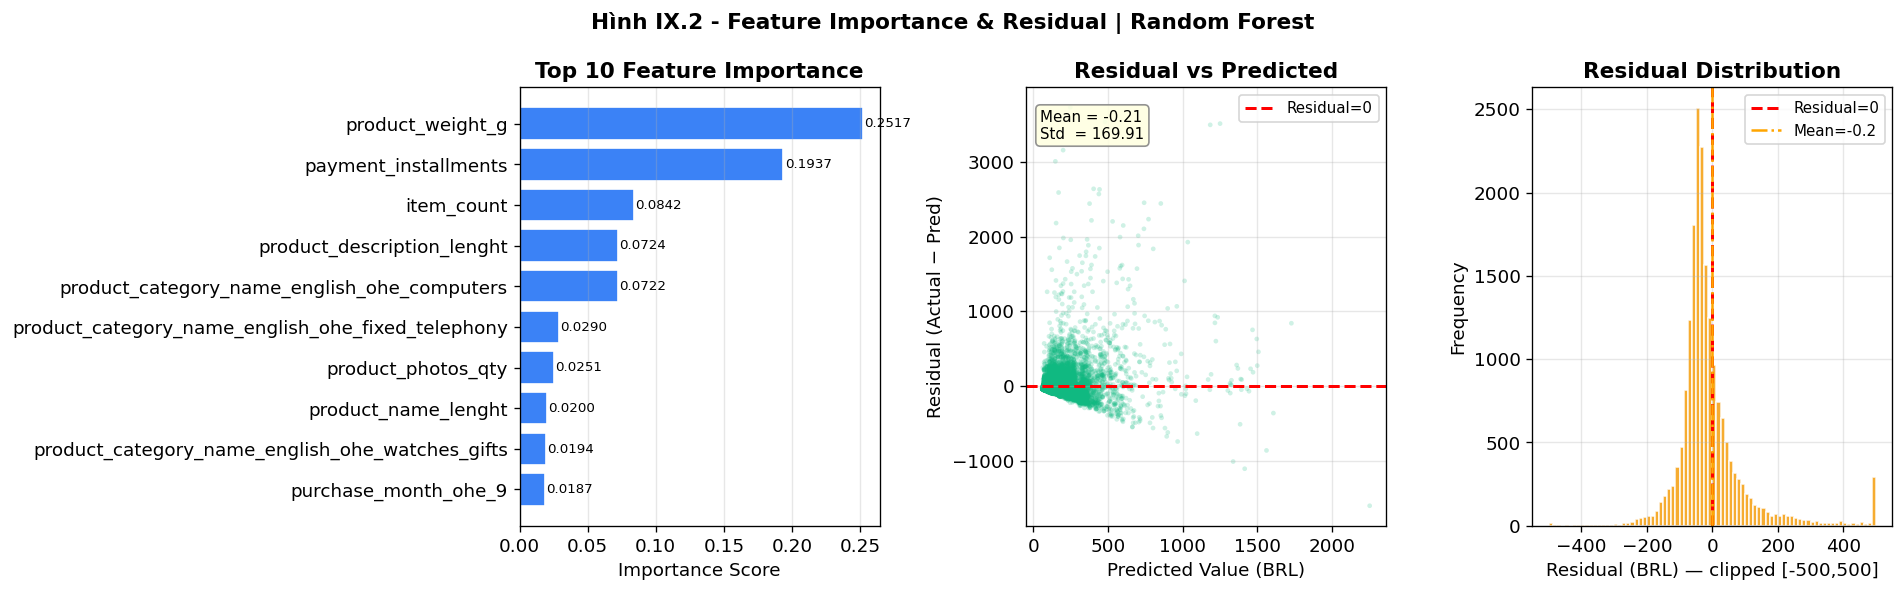

✅ Lưu fig_IX2_importance_residual.png


In [13]:
# ── 9.5 Feature Importance + Residual (Fix) ─────────────────
print("\n" + "="*60)
print("📊 9.5 FEATURE IMPORTANCE & RESIDUAL — Random Forest Regressor")
print("="*60)

rf_fitted = rf_reg_model.stages[-1]  # RandomForestRegressionModel

# ── Lấy tên feature THỰC từ metadata VectorAssembler ────────
# (OHE tạo ra nhiều cột con → tên thực nhiều hơn all_features)
from pyspark.ml.linalg import Vectors

# Lấy metadata từ output của VectorAssembler trong pipeline
assembler_model = rf_reg_model.stages[-3]  # VectorAssembler (trước scaler)
scaler_model    = rf_reg_model.stages[-2]  # StandardScaler

# Lấy tên feature từ schema của DataFrame sau transform
feat_metadata = rf_reg_model.transform(reg_test_df.limit(1)) \
    .schema["features_raw"].metadata

try:
    # Lấy tên từ metadata attrs
    num_attrs  = feat_metadata["ml_attr"]["attrs"].get("numeric", [])
    bin_attrs  = feat_metadata["ml_attr"]["attrs"].get("binary",  [])
    nom_attrs  = feat_metadata["ml_attr"]["attrs"].get("nominal", [])
    all_attrs  = num_attrs + bin_attrs + nom_attrs
    all_attrs_sorted = sorted(all_attrs, key=lambda x: x["idx"])
    real_feature_names = [a["name"] for a in all_attrs_sorted]
    print(f"✅ Số feature thực tế: {len(real_feature_names)}")
except Exception as e:
    print(f"⚠️ Không lấy được metadata: {e}")
    # Fallback: đánh số thứ tự
    n = len(rf_fitted.featureImportances.toArray())
    real_feature_names = [f"feature_{i}" for i in range(n)]

# ── Tạo DataFrame feature importance ────────────────────────
importances = rf_fitted.featureImportances.toArray()
feat_df = pd.DataFrame({
    "feature":    real_feature_names[:len(importances)],
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n🏆 Top 10 Feature Importance (Random Forest):")
print(feat_df.head(10).to_string(index=False))

# ── Residual ─────────────────────────────────────────────────
resid_pd = rf_reg_preds.select("label", "prediction").toPandas()
resid_pd["residual"] = resid_pd["label"] - resid_pd["prediction"]

print(f"\n📊 Residual Statistics:")
print(f"   Mean              : {resid_pd['residual'].mean():.4f}")
print(f"   Std               : {resid_pd['residual'].std():.4f}")
print(f"   Min               : {resid_pd['residual'].min():.4f}")
print(f"   Max               : {resid_pd['residual'].max():.4f}")
print(f"   % abs_error < 50  : {(resid_pd['residual'].abs() <  50).mean()*100:.1f}%")
print(f"   % abs_error < 100 : {(resid_pd['residual'].abs() < 100).mean()*100:.1f}%")
print(f"   % abs_error > 200 : {(resid_pd['residual'].abs() > 200).mean()*100:.1f}%")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Hình IX.2 - Feature Importance & Residual | Random Forest",
             fontweight='bold', fontsize=13)

# Subplot 1: Top 10 Feature Importance
ax1  = axes[0]
top10 = feat_df.head(10)
bars  = ax1.barh(top10["feature"][::-1], top10["importance"][::-1],
                 color=COLORS[0], edgecolor='white')
for bar, val in zip(bars, top10["importance"][::-1]):
    ax1.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va='center', fontsize=8)
ax1.set_xlabel("Importance Score")
ax1.set_title("Top 10 Feature Importance")
ax1.grid(axis='x', alpha=0.3)

# Subplot 2: Residual vs Predicted
ax2 = axes[1]
ax2.scatter(resid_pd["prediction"], resid_pd["residual"],
            alpha=0.2, s=8, color=COLORS[1], edgecolors='none')
ax2.axhline(0, color='red', lw=1.8, ls='--', label='Residual=0')
ax2.set_xlabel("Predicted Value (BRL)")
ax2.set_ylabel("Residual (Actual − Pred)")
ax2.set_title("Residual vs Predicted")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.text(0.04, 0.95,
         f"Mean = {resid_pd['residual'].mean():.2f}\n"
         f"Std  = {resid_pd['residual'].std():.2f}",
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.85))

# Subplot 3: Residual Distribution
ax3 = axes[2]
ax3.hist(resid_pd["residual"].clip(-500, 500), bins=80,
         color=COLORS[2], edgecolor='white', alpha=0.85)
ax3.axvline(0, color='red', lw=1.8, ls='--', label='Residual=0')
ax3.axvline(resid_pd["residual"].mean(), color='orange',
            lw=1.5, ls='-.',
            label=f"Mean={resid_pd['residual'].mean():.1f}")
ax3.set_xlabel("Residual (BRL) — clipped [-500,500]")
ax3.set_ylabel("Frequency")
ax3.set_title("Residual Distribution")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_IX2_importance_residual.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Lưu fig_IX2_importance_residual.png")

In [15]:
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import functions as F

# Hàm hỗ trợ tính WSSSE thủ công cho GMM (vì GMM không có thuộc tính trainingCost)
def calculate_wssse_manual(df, model_centers, prediction_col="prediction", features_col="rfm_scaled"):
    # Chuyển centers về dạng broadcast để tính toán hiệu quả
    from scipy.spatial import distance
    import numpy as np

    # Lấy các vector đặc trưng và dự đoán
    data_points = df.select(features_col, prediction_col).collect()
    total_wssse = 0.0

    for row in data_points:
        point = row[features_col].toArray()
        cluster_idx = row[prediction_col]
        center = model_centers[cluster_idx]
        total_wssse += np.sum((point - center)**2)
    return total_wssse

# --- 1. Lấy WSSSE từ K-Means ---
km_wssse = kmeans_model.summary.trainingCost

# --- 2. Lấy WSSSE từ Bisecting K-Means ---
bkm_wssse = bkm_model.summary.trainingCost

# --- 3. Tính WSSSE cho Gaussian Mixture ---
# Vì GMM không có tâm cụm cố định như K-Means (nó dùng giá trị trung bình Gauss)
# Chúng ta lấy Mean của các thành phần làm "tâm" để tính WSSSE
gmm_centers = [gauss.mean.toArray() for gauss in gmm_model.gaussiansDF.collect()]
gmm_wssse = calculate_wssse_manual(gmm_preds, gmm_centers)

# ==================== BẢNG SO SÁNH NÂNG CAO ====================
print("\n" + "="*70)
print(f"{'BẢNG SO SÁNH CHI TIẾT CÁC MÔ HÌNH (K={optimal_k})':^70}")
print("="*70)
print(f"{'Thuật toán':<25} | {'Silhouette':>12} | {'WSSSE (Inertia)':>18}")
print("-" * 70)
print(f"{'K-Means':<25} | {km_sil:>12.4f} | {km_wssse:>18.2f}")
print(f"{'Bisecting K-Means':<25} | {bkm_sil:>12.4f} | {bkm_wssse:>18.2f}")
print(f"{'Gaussian Mixture':<25} | {gmm_sil:>12.4f} | {gmm_wssse:>18.2f}")
print("="*70)
print("> Ghi chú: WSSSE càng thấp, các điểm trong cụm càng gần nhau.")
print("> Silhouette càng gần 1, các cụm càng tách biệt tốt.")


          BẢNG SO SÁNH CHI TIẾT CÁC MÔ HÌNH (K={optimal_k})           
Thuật toán                |   Silhouette |    WSSSE (Inertia)
----------------------------------------------------------------------
K-Means                   |       0.6530 |           94358.80
Bisecting K-Means         |       0.5600 |          136878.57
Gaussian Mixture          |       0.7502 |          159381.86
> Ghi chú: WSSSE càng thấp, các điểm trong cụm càng gần nhau.
> Silhouette càng gần 1, các cụm càng tách biệt tốt.


In [16]:
# ==================== TẠO BẢNG VII.4: TOP 5 LUẬT KẾT HỢP ====================
print("\n" + "="*60)
print("📋 BẢNG VII.4: TOP 5 LUẬT KẾT HỢP TỪ FP-GROWTH")
print("="*60)

if n_rules > 0:
    from pyspark.sql.functions import concat_ws, col

    # Lấy top 5 rules theo lift, format antecedent/consequent thành chuỗi
    top5_rules = assoc_rules \
        .withColumn("Antecedent", concat_ws(", ", col("antecedent"))) \
        .withColumn("Consequent", concat_ws(", ", col("consequent"))) \
        .withColumn("Support",    F.round(col("support"),    4)) \
        .withColumn("Confidence", F.round(col("confidence"), 4)) \
        .withColumn("Lift",       F.round(col("lift"),       4)) \
        .select("Antecedent", "Consequent", "Support", "Confidence", "Lift") \
        .orderBy(F.col("Lift").desc()) \
        .limit(5)

    # Hiển thị dạng bảng Spark
    top5_rules.show(truncate=False)

    # ── Xuất bảng đẹp bằng pandas ──────────────────────────────
    top5_pd = top5_rules.toPandas()

    try:
        from IPython.display import display, HTML

        html_table = top5_pd.to_html(index=False, border=1, justify="center")

        # Style giống bảng trong báo cáo
        styled_html = f"""
        <style>
            .fp-table {{
                border-collapse: collapse;
                width: 100%;
                font-family: Arial, sans-serif;
                font-size: 13px;
            }}
            .fp-table th {{
                background-color: #1a3c5e;
                color: white;
                padding: 8px 12px;
                text-align: center;
                border: 1px solid #ccc;
            }}
            .fp-table td {{
                padding: 7px 12px;
                text-align: center;
                border: 1px solid #ccc;
            }}
            .fp-table tr:nth-child(even) {{
                background-color: #f2f2f2;
            }}
            .fp-table caption {{
                font-weight: bold;
                margin-bottom: 6px;
                font-size: 14px;
            }}
        </style>
        <table class="fp-table">
            <caption>Bảng VII.4. Top 5 luật kết hợp từ FP-Growth</caption>
            <thead>
                <tr>
                    {''.join(f'<th>{col}</th>' for col in top5_pd.columns)}
                </tr>
            </thead>
            <tbody>
                {''.join(
                    '<tr>' + ''.join(f'<td>{v}</td>' for v in row) + '</tr>'
                    for row in top5_pd.values
                )}
            </tbody>
        </table>
        """
        display(HTML(styled_html))

    except ImportError:
        # Fallback: tabulate nếu không có IPython
        try:
            from tabulate import tabulate
            print(tabulate(top5_pd, headers="keys", tablefmt="grid", showindex=False))
        except ImportError:
            print(top5_pd.to_string(index=False))

else:
    print("⚠️  Không có association rules để hiển thị bảng.")


📋 BẢNG VII.4: TOP 5 LUẬT KẾT HỢP TỪ FP-GROWTH
+-------------------------+---------------+-------+----------+------+
|Antecedent               |Consequent     |Support|Confidence|Lift  |
+-------------------------+---------------+-------+----------+------+
|musical_instruments      |toys           |0.0026 |0.3077    |3.7553|
|drinks                   |telephony      |0.0026 |0.2222    |3.5147|
|food                     |perfumery      |0.0026 |0.2222    |3.4103|
|food_drink               |sports_leisure |0.0026 |0.4444    |3.1171|
|construction_tools_lights|furniture_decor|0.0045 |0.5833    |2.7566|
+-------------------------+---------------+-------+----------+------+



Antecedent,Consequent,Support,Confidence,Lift
musical_instruments,toys,0.0026,0.3077,3.7553
drinks,telephony,0.0026,0.2222,3.5147
food,perfumery,0.0026,0.2222,3.4103
food_drink,sports_leisure,0.0026,0.4444,3.1171
construction_tools_lights,furniture_decor,0.0045,0.5833,2.7566


In [17]:
# ==================== BẢNG KẾT QUẢ ALS ====================
print("\n" + "="*60)
print("📊 KẾT QUẢ MÔ HÌNH ALS - RECOMMENDATION")
print("="*60)

# ── 1. In RMSE ──────────────────────────────────────────────
print(f"\n📉 RMSE trên tập test: {als_rmse:.4f}")

# ── 2. Map ngược idx → ID thật ──────────────────────────────
# Lấy mapping customer_idx ↔ customer_unique_id
customer_map = als_index_model.stages[0] \
    .labels  # StringIndexerModel lưu labels theo thứ tự index

product_map = als_index_model.stages[1] \
    .labels  # index 0 → labels[0], index 1 → labels[1], ...

# ── 3. Lấy top 10 cho 3 khách hàng mẫu ─────────────────────
sample_users = als_data_indexed.select("customer_idx").distinct().limit(3)
user_recs    = als_model_fitted.recommendForUserSubset(sample_users, 10)

# ── 4. Explode + map về ID thật ─────────────────────────────
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

get_customer_id = udf(
    lambda idx: customer_map[int(idx)] if int(idx) < len(customer_map) else "unknown",
    StringType()
)
get_product_id = udf(
    lambda idx: product_map[int(idx)] if int(idx) < len(product_map) else "unknown",
    StringType()
)

recs_exploded = user_recs \
    .withColumn("rec", F.explode("recommendations")) \
    .withColumn("product_idx_raw", F.col("rec.product_idx").cast("int")) \
    .withColumn("predicted_score", F.round(F.col("rec.rating"), 4)) \
    .withColumn("customer_id",  get_customer_id(F.col("customer_idx").cast("int"))) \
    .withColumn("product_id",   get_product_id(F.col("product_idx_raw"))) \
    .withColumn("rank", F.row_number().over(
        Window.partitionBy("customer_idx").orderBy(F.col("predicted_score").desc())
    )) \
    .select("customer_id", "rank", "product_id", "predicted_score")

# ── 5. Hiển thị bảng đẹp bằng pandas ───────────────────────
recs_pd = recs_exploded.toPandas()

try:
    from IPython.display import display, HTML

    # Group theo customer, tạo sub-table cho từng người
    html_parts = ["""
    <style>
        .als-wrap { font-family: Arial, sans-serif; font-size: 13px; margin-bottom: 20px; }
        .als-title { font-weight: bold; font-size: 14px; margin: 10px 0 4px 0; color: #1a3c5e; }
        .als-rmse  { font-size: 13px; margin-bottom: 14px; }
        .als-table { border-collapse: collapse; width: 100%; }
        .als-table th { background-color: #1a3c5e; color: white;
                        padding: 7px 12px; text-align: center; border: 1px solid #ccc; }
        .als-table td { padding: 6px 12px; text-align: center; border: 1px solid #ccc; }
        .als-table tr:nth-child(even) { background-color: #f2f2f2; }
        .als-caption { font-weight: bold; text-align: center;
                       margin: 18px 0 6px 0; font-size: 14px; }
    </style>
    <div class="als-wrap">
    """]

    # RMSE header
    html_parts.append(f'<div class="als-rmse">📉 <b>RMSE trên tập test: {als_rmse:.4f}</b></div>')
    html_parts.append('<div class="als-caption">Hình VII.5. Top 10 khuyến nghị cho 3 khách hàng mẫu</div>')

    for cust_id in recs_pd["customer_id"].unique():
        sub = recs_pd[recs_pd["customer_id"] == cust_id].reset_index(drop=True)
        short_id = cust_id[:16] + "..." if len(cust_id) > 16 else cust_id

        html_parts.append(f'<div class="als-title">👤 Khách hàng: {short_id}</div>')
        html_parts.append('<table class="als-table"><thead><tr>')
        html_parts.append('<th>#</th><th>Product ID</th><th>Predicted Score</th>')
        html_parts.append('</tr></thead><tbody>')

        for _, row in sub.iterrows():
            prod_short = row["product_id"][:20] + "..." if len(str(row["product_id"])) > 20 else row["product_id"]
            html_parts.append(
                f'<tr><td>{row["rank"]}</td>'
                f'<td>{prod_short}</td>'
                f'<td>{row["predicted_score"]:.4f}</td></tr>'
            )
        html_parts.append('</tbody></table><br>')

    html_parts.append('</div>')
    display(HTML("".join(html_parts)))

except ImportError:
    # Fallback plain text
    print(f"\nRMSE trên tập test: {als_rmse:.4f}")
    print("\nTop 10 Recommendations cho 3 khách hàng mẫu:")
    print(recs_pd.to_string(index=False))


📊 KẾT QUẢ MÔ HÌNH ALS - RECOMMENDATION

📉 RMSE trên tập test: 4.0514


#,Product ID,Predicted Score
1,32e18e89237933ebdaae...,4.9309
2,66f4a4e7df716d7d67d8...,3.5960
3,c92af8ae65f217933c22...,3.5058
4,b4f9530c931398e21524...,3.4705
5,908c23dd2b637d8ff1a4...,3.4381
6,ee57070aa3b24a06fdd0...,3.4238
7,aded994da51233ec2f2b...,3.3162
8,5296c5bfef0fca38d057...,3.3008
9,a6509ce76da01c1027fe...,3.2534
10,ba05e2861971098fc7ec...,3.2353


In [18]:
# ==================== MAP NGƯỢC idx → ID THẬT ====================

# ── 1. Tạo mapping tables từ StringIndexerModel ──────────────
customer_labels = als_index_model.stages[0].labels  # list: index → customer_unique_id
product_labels  = als_index_model.stages[1].labels  # list: index → product_id

# Tạo Spark DataFrame mapping
customer_mapping = spark.createDataFrame(
    [(float(i), v) for i, v in enumerate(customer_labels)],
    ["customer_idx", "customer_unique_id"]
)
product_mapping = spark.createDataFrame(
    [(float(i), v) for i, v in enumerate(product_labels)],
    ["product_idx", "product_id"]
)

# ── 2. Explode recommendations + join map ────────────────────
sample_users    = als_data_indexed.select("customer_idx").distinct().limit(3)
user_recs       = als_model_fitted.recommendForUserSubset(sample_users, 10)

recommendations_df = user_recs \
    .withColumn("rec", F.explode("recommendations")) \
    .withColumn("product_idx", F.col("rec.product_idx").cast("double")) \
    .withColumn("score",       F.round(F.col("rec.rating"), 4)) \
    .select("customer_idx", "product_idx", "score")

# ── 3. Join map ngược về ID thật ─────────────────────────────
result_df = recommendations_df \
    .join(customer_mapping, on="customer_idx", how="left") \
    .join(product_mapping,  on="product_idx",  how="left") \
    .withColumn("rank", F.row_number().over(
        Window.partitionBy("customer_idx").orderBy(F.col("score").desc())
    )) \
    .select("customer_unique_id", "rank", "product_id", "score") \
    .orderBy("customer_unique_id", "rank")

# ── 4. Hiển thị kết quả ──────────────────────────────────────
print("\n🎁 Top 10 Recommendations (đã map về ID thật):")
result_df.show(30, truncate=True)

# ── 5. Render bảng HTML đẹp (Jupyter/Databricks) ─────────────
result_pd = result_df.toPandas()

try:
    from IPython.display import display, HTML

    html_parts = ["""
    <style>
        .als-wrap  { font-family: Arial, sans-serif; font-size: 13px; }
        .als-rmse  { margin-bottom: 14px; }
        .als-cname { font-weight: bold; color: #1a3c5e;
                     margin: 14px 0 4px 0; font-size: 13px; }
        .als-table { border-collapse: collapse; width: 100%; margin-bottom: 10px; }
        .als-table th { background-color: #1a3c5e; color: white;
                        padding: 7px 12px; text-align: center; border: 1px solid #ccc; }
        .als-table td { padding: 6px 12px; text-align: center; border: 1px solid #ccc; }
        .als-table tr:nth-child(even) { background-color: #f2f2f2; }
        .als-caption { font-weight: bold; text-align: center;
                       margin: 0 0 12px 0; font-size: 14px; }
    </style>
    <div class="als-wrap">
    """]

    html_parts.append(f'<div class="als-rmse">📉 <b>RMSE trên tập test: {als_rmse:.4f}</b></div>')
    html_parts.append('<div class="als-caption">Hình VII.5. Top 10 khuyến nghị cho 3 khách hàng mẫu</div>')

    for cust_id in result_pd["customer_unique_id"].unique():
        sub      = result_pd[result_pd["customer_unique_id"] == cust_id].reset_index(drop=True)
        short_id = str(cust_id)[:20] + "..." if len(str(cust_id)) > 20 else str(cust_id)

        html_parts.append(f'<div class="als-cname">👤 {short_id}</div>')
        html_parts.append('<table class="als-table"><thead><tr>'
                          '<th>#</th><th>Product ID</th><th>Predicted Score</th>'
                          '</tr></thead><tbody>')

        for _, row in sub.iterrows():
            pid = str(row["product_id"])
            pid_disp = pid[:28] + "..." if len(pid) > 28 else pid
            html_parts.append(
                f'<tr><td>{row["rank"]}</td>'
                f'<td>{pid_disp}</td>'
                f'<td>{row["score"]:.4f}</td></tr>'
            )
        html_parts.append('</tbody></table>')

    html_parts.append('</div>')
    display(HTML("".join(html_parts)))

except ImportError:
    print(result_pd.to_string(index=False))


🎁 Top 10 Recommendations (đã map về ID thật):
+--------------------+----+--------------------+------+
|  customer_unique_id|rank|          product_id| score|
+--------------------+----+--------------------+------+
|0782c41380992a5a5...|   1|32e18e89237933ebd...|4.9309|
|0782c41380992a5a5...|   2|66f4a4e7df716d7d6...| 3.596|
|0782c41380992a5a5...|   3|c92af8ae65f217933...|3.5058|
|0782c41380992a5a5...|   4|b4f9530c931398e21...|3.4705|
|0782c41380992a5a5...|   5|908c23dd2b637d8ff...|3.4381|
|0782c41380992a5a5...|   6|ee57070aa3b24a06f...|3.4238|
|0782c41380992a5a5...|   7|aded994da51233ec2...|3.3162|
|0782c41380992a5a5...|   8|5296c5bfef0fca38d...|3.3008|
|0782c41380992a5a5...|   9|a6509ce76da01c102...|3.2534|
|0782c41380992a5a5...|  10|ba05e2861971098fc...|3.2353|
|3fb97204945ca0c01...|   1|04566e1a1afa83470...|4.9324|
|3fb97204945ca0c01...|   2|a8385505c3cdcbf7c...|4.0351|
|3fb97204945ca0c01...|   3|c33a764dad4f6747f...|3.6048|
|3fb97204945ca0c01...|   4|c6e4094f85503e051...|3.4477|
|

#,Product ID,Predicted Score
1,32e18e89237933ebdaaebd78a27e...,4.9309
2,66f4a4e7df716d7d67d81496ccc1...,3.5960
3,c92af8ae65f217933c222f02ab10...,3.5058
4,b4f9530c931398e215242293c2c8...,3.4705
5,908c23dd2b637d8ff1a4e593a5b2...,3.4381
6,ee57070aa3b24a06fdd0e02efd2d...,3.4238
7,aded994da51233ec2f2b7eaa78ef...,3.3162
8,5296c5bfef0fca38d0572263011f...,3.3008
9,a6509ce76da01c1027fea6d7aae4...,3.2534
10,ba05e2861971098fc7ecd8162c23...,3.2353



📋 13.5 Bảng tổng hợp Regression metrics:
                  model     rmse     mae     r2  train_time
      Linear Regression 175.0504 84.3968 0.3481       24.36
Decision Tree Regressor 177.9817 81.4632 0.3261       16.32
Random Forest Regressor 169.9044 79.0357 0.3859       71.05

🏆 Best model (R²): Random Forest Regressor (R²=0.3859, RMSE=169.9044)


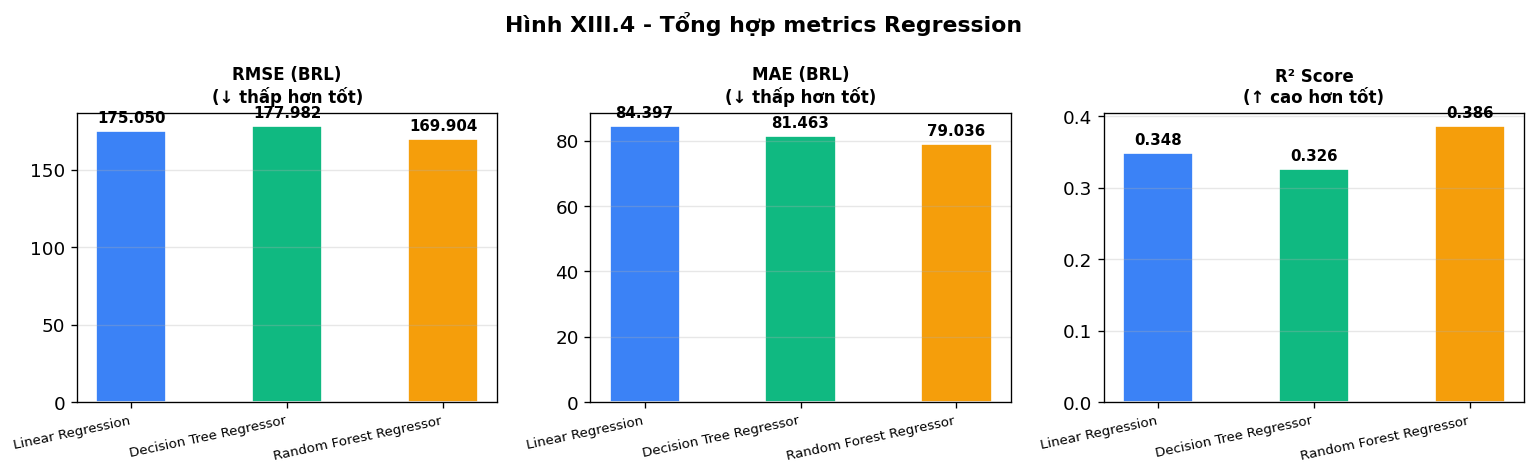

In [19]:

# ── 13.5 Tổng hợp Regression metrics ────────────────────────
print("\n📋 13.5 Bảng tổng hợp Regression metrics:")
reg_summary = pd.DataFrame(reg_results)
print(reg_summary.round(4).to_string(index=False))

best_reg_idx  = reg_summary["r2"].idxmax()
best_reg_name = reg_summary.loc[best_reg_idx, "model"]
print(f"\n🏆 Best model (R²): {best_reg_name} "
      f"(R²={reg_summary.loc[best_reg_idx,'r2']:.4f}, "
      f"RMSE={reg_summary.loc[best_reg_idx,'rmse']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Hình XIII.4 - Tổng hợp metrics Regression", fontweight='bold')

for ax, metric, ylabel, note in zip(
    axes,
    ["rmse", "mae", "r2"],
    ["RMSE (BRL)", "MAE (BRL)", "R² Score"],
    ["↓ thấp hơn tốt", "↓ thấp hơn tốt", "↑ cao hơn tốt"]
):
    bars = ax.bar(reg_summary["model"], reg_summary[metric],
                  color=COLORS[:3], edgecolor='white', width=0.45)
    ax.set_title(f"{ylabel}\n({note})", fontsize=10)
    ax.set_xticklabels(reg_summary["model"], rotation=12, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, reg_summary[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(reg_summary[metric])*0.02,
                f"{val:.3f}", ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("fig_XIII4_reg_summary.png", bbox_inches='tight', dpi=120)
plt.show()


📊 9.4 Predicted vs Actual Plot - Best Model


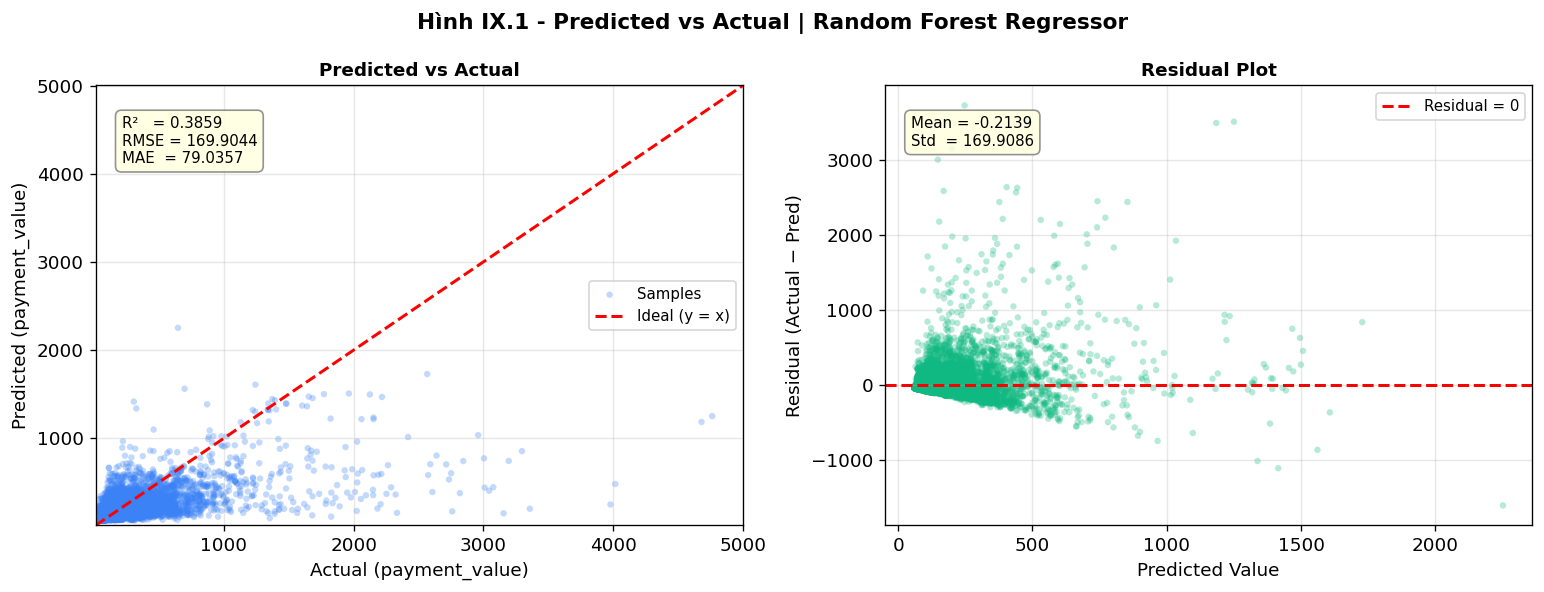

   Best model: Random Forest Regressor | R²=0.3859 | RMSE=169.9044 | MAE=79.0357


In [20]:
# ── 9.4 Predicted vs Actual Plot - Best Model ────────────────
print("\n📊 9.4 Predicted vs Actual Plot - Best Model")

# Xác định best model từ reg_results
reg_summary    = pd.DataFrame(reg_results)
best_reg_idx   = reg_summary["r2"].idxmax()
best_reg_name  = reg_summary.loc[best_reg_idx, "model"]

# Map tên → model + predictions có sẵn
_model_map = {
    "Linear Regression"      : (lr_reg_model, lr_reg_preds),
    "Decision Tree Regressor": (dt_reg_model, dt_reg_preds),
    "Random Forest Regressor": (rf_reg_model, rf_reg_preds),
}
_, best_preds = _model_map[best_reg_name]

# Lấy pandas
best_pd   = best_preds.select("label", "prediction").toPandas()
y_actual  = best_pd["label"]
y_pred    = best_pd["prediction"]
residuals = y_actual - y_pred

r2   = float(reg_summary.loc[best_reg_idx, "r2"])
rmse = float(reg_summary.loc[best_reg_idx, "rmse"])
mae  = float(reg_summary.loc[best_reg_idx, "mae"])

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Hình IX.1 - Predicted vs Actual | {best_reg_name}",
             fontweight='bold', fontsize=13)

# --- Subplot 1: Scatter Predicted vs Actual ------------------
ax1 = axes[0]
lim_min = min(y_actual.min(), y_pred.min()) * 0.95
lim_max = max(y_actual.max(), y_pred.max()) * 1.05

ax1.scatter(y_actual, y_pred,
            alpha=0.3, s=15, color=COLORS[0],
            edgecolors='none', label='Samples')
ax1.plot([lim_min, lim_max], [lim_min, lim_max],
         color='red', lw=1.8, ls='--', label='Ideal (y = x)')
ax1.set_xlim(lim_min, lim_max)
ax1.set_ylim(lim_min, lim_max)
ax1.set_xlabel("Actual (payment_value)",    fontsize=11)
ax1.set_ylabel("Predicted (payment_value)", fontsize=11)
ax1.set_title("Predicted vs Actual",        fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.text(0.04, 0.93,
         f"R²   = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE  = {mae:.4f}",
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.85))

# --- Subplot 2: Residual Plot --------------------------------
ax2 = axes[1]
ax2.scatter(y_pred, residuals,
            alpha=0.3, s=15, color=COLORS[1], edgecolors='none')
ax2.axhline(0, color='red', lw=1.8, ls='--', label='Residual = 0')
ax2.set_xlabel("Predicted Value",          fontsize=11)
ax2.set_ylabel("Residual (Actual − Pred)", fontsize=11)
ax2.set_title("Residual Plot",             fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.text(0.04, 0.93,
         f"Mean = {residuals.mean():.4f}\nStd  = {residuals.std():.4f}",
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.85))

plt.tight_layout()
plt.savefig("fig_IX1_pred_vs_actual.png", bbox_inches='tight', dpi=120)
plt.show()
print(f"   Best model: {best_reg_name} | R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")

In [21]:
# ==================== EXPORT FILES CHO STREAMLIT ====================
# Thêm cell này vào CUỐI notebook và chạy sau khi đã chạy hết tất cả phần
# Dựa vào các biến thực tế trong notebook:
#   clf_results      → list dict từ phần 7
#   reg_results      → list dict từ phần 9
#   rfm_clustered    → DataFrame từ phần 10 (K-Means)
#   assoc_rules      → DataFrame từ phần 12 (FP-Growth)
#   als_index_model  → Pipeline model từ phần 11
# =====================================================================

import os, json
import pandas as pd

MODEL_PATH = "./models/"
os.makedirs(MODEL_PATH, exist_ok=True)
print("📂 Bắt đầu export files cho Streamlit...")
print(f"   Thư mục lưu: {MODEL_PATH}")
print("="*50)

# ── 1. clf_results.csv — từ phần 7 ──────────────────────────
try:
    # clf_results là list các dict: [{"model":..,"accuracy":..,"f1":..,"auc":..,"train_time":..}, ...]
    clf_pd = pd.DataFrame(clf_results)

    # Thêm kết quả CV (phần 8) nếu có
    try:
        cv_extra = []
        if "rf_cv_acc" in dir():
            cv_extra.append({
                "model": "Random Forest (CV)",
                "accuracy": rf_cv_acc, "precision": rf_cv_prec,
                "recall": rf_cv_rec, "f1": rf_cv_f1,
                "auc": rf_cv_auc, "train_time": round(rf_tune_time, 2)
            })
        if "gbt_tvs_auc" in dir():
            cv_extra.append({
                "model": "GBTClassifier (CV)",
                "accuracy": 0.0, "precision": 0.0,
                "recall": 0.0, "f1": 0.0,
                "auc": gbt_tvs_auc, "train_time": round(gbt_tune_time, 2)
            })
        if cv_extra:
            clf_pd = pd.concat([clf_pd, pd.DataFrame(cv_extra)], ignore_index=True)
    except Exception:
        pass

    clf_pd.to_csv(MODEL_PATH + "clf_results.csv", index=False)
    print(f"✅ clf_results.csv ({len(clf_pd)} models)")
    print(f"   Models: {clf_pd['model'].tolist()}")
except NameError:
    print("❌ clf_results chưa có → chạy phần 7 trước")

# ── 2. reg_results.csv — từ phần 9 ──────────────────────────
try:
    # reg_results là list các dict: [{"model":..,"rmse":..,"mae":..,"r2":..,"train_time":..}, ...]
    reg_pd = pd.DataFrame(reg_results)
    reg_pd.to_csv(MODEL_PATH + "reg_results.csv", index=False)
    print(f"✅ reg_results.csv ({len(reg_pd)} models)")
    print(f"   Models: {reg_pd['model'].tolist()}")
except NameError:
    print("❌ reg_results chưa có → chạy phần 9 trước")

# ── 3. rfm_clusters.csv — từ phần 10 ────────────────────────
try:
    # rfm_clustered có cột: customer_unique_id, Recency, Frequency, Monetary,
    #                        rfm_features (vector), rfm_scaled (vector), prediction
    # Chỉ lấy các cột cần thiết cho Streamlit (bỏ vector columns)
    rfm_export = rfm_clustered.select(
        "customer_unique_id",
        "Recency",
        "Frequency",
        "Monetary",
        "prediction"
    ).toPandas()

    rfm_export.to_csv(MODEL_PATH + "rfm_clusters.csv", index=False)
    print(f"✅ rfm_clusters.csv ({len(rfm_export):,} khách hàng)")
    print(f"   Clusters: {sorted(rfm_export['prediction'].unique().tolist())}")
    print(f"   Phân bố: {rfm_export['prediction'].value_counts().to_dict()}")
except NameError:
    print("❌ rfm_clustered chưa có → chạy phần 10 trước")
    print("   Đang tạo lại rfm_clustered từ rfm_df...")
    try:
        from pyspark.ml.clustering import KMeans
        k = optimal_k if "optimal_k" in dir() else 4
        _km = KMeans(featuresCol="rfm_scaled", k=k, seed=42, maxIter=100)
        rfm_clustered = _km.fit(rfm_df).transform(rfm_df)
        rfm_clustered.cache()
        rfm_export = rfm_clustered.select(
            "customer_unique_id", "Recency", "Frequency", "Monetary", "prediction"
        ).toPandas()
        rfm_export.to_csv(MODEL_PATH + "rfm_clusters.csv", index=False)
        print(f"✅ rfm_clusters.csv (tạo lại, {len(rfm_export):,} khách hàng)")
    except Exception as e:
        print(f"❌ Không tạo được rfm_clusters.csv: {e}")

# ── 4. association_rules.csv — từ phần 12 ───────────────────
try:
    # assoc_rules có cột: antecedent (array), consequent (array),
    #                      confidence, lift, support
    ar_export = assoc_rules.toPandas()

    # Convert array columns sang string để lưu CSV
    ar_export["antecedent"] = ar_export["antecedent"].apply(
        lambda x: str(list(x)) if hasattr(x, "__iter__") else str(x)
    )
    ar_export["consequent"] = ar_export["consequent"].apply(
        lambda x: str(list(x)) if hasattr(x, "__iter__") else str(x)
    )

    ar_export.to_csv(MODEL_PATH + "association_rules.csv", index=False)
    print(f"✅ association_rules.csv ({len(ar_export)} rules)")
    if len(ar_export) > 0:
        print(f"   Lift range: {ar_export['lift'].min():.3f} ~ {ar_export['lift'].max():.3f}")
        print(f"   Confidence range: {ar_export['confidence'].min():.3f} ~ {ar_export['confidence'].max():.3f}")
    else:
        print("   ⚠️  0 rules — giảm minSupport/minConfidence trong phần 12")
except NameError:
    print("❌ assoc_rules chưa có → chạy phần 12 trước")

# ── 5. als_customer_labels.json — từ phần 11 ────────────────
try:
    # als_index_model là Pipeline fit của [customer_indexer, product_indexer]
    # stages[0] = customer StringIndexerModel → .labels = list customer_unique_id
    # stages[1] = product  StringIndexerModel → .labels = list product_id
    customer_labels = list(als_index_model.stages[0].labels)
    product_labels  = list(als_index_model.stages[1].labels)

    with open(MODEL_PATH + "als_customer_labels.json", "w") as f:
        json.dump(customer_labels, f)
    print(f"✅ als_customer_labels.json ({len(customer_labels):,} customers)")

    with open(MODEL_PATH + "als_product_labels.json", "w") as f:
        json.dump(product_labels, f)
    print(f"✅ als_product_labels.json ({len(product_labels):,} products)")

except NameError:
    print("❌ als_index_model chưa có → chạy phần 11 trước")
except Exception as e:
    print(f"❌ Lỗi ALS labels: {e}")

# ── Kiểm tra tổng kết ────────────────────────────────────────
print("\n" + "="*50)
print("📋 TỔNG KẾT FILES ĐÃ TẠO:")
print("="*50)
expected_files = [
    "clf_results.csv",
    "reg_results.csv",
    "rfm_clusters.csv",
    "association_rules.csv",
    "als_customer_labels.json",
    "als_product_labels.json",
]
all_ok = True
for fname in expected_files:
    fpath = MODEL_PATH + fname
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        print(f"  ✅ {fname:<35} ({size:>10,} bytes)")
    else:
        print(f"  ❌ {fname:<35} THIẾU")
        all_ok = False

if all_ok:
    print("\n🎉 Tất cả files đã sẵn sàng cho Streamlit!")
else:
    print("\n⚠️  Một số files chưa có — chạy lại các phần bị thiếu")

# ── Download ZIP về máy ──────────────────────────────────────
import shutil
shutil.make_archive("streamlit_models", "zip", MODEL_PATH)

from google.colab import files
files.download("streamlit_models.zip")
print("\n✅ Download streamlit_models.zip thành công!")
print("   → Giải nén và đặt vào thư mục models/ cạnh app.py")

📂 Bắt đầu export files cho Streamlit...
   Thư mục lưu: ./models/
✅ clf_results.csv (7 models)
   Models: ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'LinearSVC', 'GBTClassifier', 'Random Forest (CV)', 'GBTClassifier (CV)']
✅ reg_results.csv (3 models)
   Models: ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor']
✅ rfm_clusters.csv (95,419 khách hàng)
   Clusters: [0, 1, 2, 3]
   Phân bố: {0: 52015, 1: 38053, 3: 2881, 2: 2470}
✅ association_rules.csv (61 rules)
   Lift range: 0.444 ~ 3.755
   Confidence range: 0.100 ~ 0.583
✅ als_customer_labels.json (94,720 customers)
✅ als_product_labels.json (31,724 products)

📋 TỔNG KẾT FILES ĐÃ TẠO:
  ✅ clf_results.csv                     (       804 bytes)
  ✅ reg_results.csv                     (       281 bytes)
  ✅ rfm_clusters.csv                    ( 4,527,188 bytes)
  ✅ association_rules.csv               (     5,877 bytes)
  ✅ als_customer_labels.json            ( 3,409,920 bytes)
  ✅ als_product_labels

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download streamlit_models.zip thành công!
   → Giải nén và đặt vào thư mục models/ cạnh app.py


In [23]:
# ── Kiểm tra Overfitting - GBTClassifier (best model) ───────
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

# Thay "gbt_model" bằng đúng tên biến pipeline model GBT của bạn
# Thường là: gbt_model, gbt_pipeline_model, clf_models["GBT"], ...
gbt_fitted = gbt_model   # ← SỬA tên biến này

# Transform trên cả train và test
gbt_train_preds = gbt_fitted.transform(train_features)
gbt_test_preds  = gbt_fitted.transform(test_features)

train_acc = evaluator_acc.evaluate(gbt_train_preds)
test_acc  = evaluator_acc.evaluate(gbt_test_preds)
train_auc = evaluator_auc.evaluate(gbt_train_preds)
test_auc  = evaluator_auc.evaluate(gbt_test_preds)

print("="*50)
print("📊 Overfitting Check - GBTClassifier")
print("="*50)
print(f"{'Metric':<15} {'Train':>10} {'Test':>10} {'Gap':>10}")
print("-"*45)
print(f"{'Accuracy':<15} {train_acc:>10.4f} {test_acc:>10.4f} {train_acc-test_acc:>10.4f}")
print(f"{'AUC-ROC':<15} {train_auc:>10.4f} {test_auc:>10.4f} {train_auc-test_auc:>10.4f}")
print("-"*45)
print(f"→ Gap Accuracy : {'⚠️ Overfit' if train_acc-test_acc > 0.05 else '✅ Bình thường'}")
print(f"→ Gap AUC-ROC  : {'⚠️ Overfit' if train_auc-test_auc > 0.05 else '✅ Bình thường'}")

📊 Overfitting Check - GBTClassifier
Metric               Train       Test        Gap
---------------------------------------------
Accuracy            0.7751     0.7749     0.0002
AUC-ROC             0.6689     0.6223     0.0466
---------------------------------------------
→ Gap Accuracy : ✅ Bình thường
→ Gap AUC-ROC  : ✅ Bình thường


In [25]:
# Thử lần lượt để biết tên đúng
print(dir())  # liệt kê tất cả biến đang có trong memory

['ALS', 'ArrayType', 'BinaryClassificationEvaluator', 'BinaryType', 'BisectingKMeans', 'BooleanType', 'ByteType', 'COLORS', 'CalendarIntervalType', 'CharType', 'ChiSqSelector', 'ClusteringEvaluator', 'CountVectorizer', 'CrossValidator', 'DATA_PATH', 'DataType', 'DateType', 'DayTimeIntervalType', 'DecimalType', 'DecisionTreeRegressor', 'DoubleType', 'F', 'FPGrowth', 'FloatType', 'GBTClassifier', 'GaussianMixture', 'HTML', 'IDF', 'In', 'IntegerType', 'KMeans', 'K_range', 'LinearRegression', 'LinearSVC', 'LogisticRegression', 'LongType', 'MODEL_PATH', 'MapType', 'MinMaxScaler', 'MulticlassClassificationEvaluator', 'NaiveBayes', 'NullType', 'OneHotEncoder', 'Out', 'PCA', 'ParamGridBuilder', 'Pipeline', 'REF_DATE', 'RandomForestClassifier', 'RandomForestRegressor', 'RegressionEvaluator', 'Row', 'ShortType', 'SparkCorr', 'SparkSession', 'StandardScaler', 'StopWordsRemover', 'StringIndexer', 'StringType', 'StructField', 'StructType', 'TimestampNTZType', 'TimestampType', 'Tokenizer', 'TrainVal

In [29]:
print("\n📊 Phân bố label (train):")
train_df.groupBy("label").count().show()

print("\n📊 Phân bố label (test):")
test_df.groupBy("label").count().show()


📊 Phân bố label (train):
+-----+-----+
|label|count|
+-----+-----+
|  1.0|60840|
|  0.0|18318|
+-----+-----+


📊 Phân bố label (test):
+-----+-----+
|label|count|
+-----+-----+
|  1.0|15109|
|  0.0| 4398|
+-----+-----+



In [30]:
from pyspark.sql import functions as F

train_dist = train_df.groupBy("label").count()
total = train_df.count()

train_dist = train_dist.withColumn(
    "percentage",
    F.round(F.col("count") / total * 100, 2)
)

print("\n📊 Tỷ lệ label (train):")
train_dist.show()


📊 Tỷ lệ label (train):
+-----+-----+----------+
|label|count|percentage|
+-----+-----+----------+
|  1.0|60840|     76.86|
|  0.0|18318|     23.14|
+-----+-----+----------+



In [31]:
counts = train_df.groupBy("label").count().collect()

count_dict = {row["label"]: row["count"] for row in counts}

majority = max(count_dict.values())
minority = min(count_dict.values())

imbalance_ratio = majority / minority

print(f"\n⚖️ Imbalance ratio: {imbalance_ratio:.2f}")


⚖️ Imbalance ratio: 3.32
